# DMSO replicate discrepancy under different |logFC| thresholds

For each perturbation we look up its ashr-shrunken logFC vector in the two
DMSO contexts:

- batch 1 → `PosteriorMean_matrix_DMSO_round2.csv`
- batch 2 → `PosteriorMean_matrix_DMSO_round2_batch2.csv`

For a sweep of thresholds $\tau$ we compute a **sign-aware (sign-matched)
Jaccard** of the two batches' DE-gene sets per perturbation. A gene is **DE**
for a perturbation in a context iff

$$\text{FDR}_{p,g} < 0.05 \quad\text{(from }\texttt{FDR\_matrices/}\text{)} \quad\land\quad |\beta_{p,g}| \ge \tau,$$

and it *agrees* between the two batches only if it is DE in **both** **with the
same sign** of effect. The union is the set of genes DE in either batch.

> We use the FDR-gated, sign-aware overlap throughout. An unsigned overlap — a
> gene *up* in one batch and *down* in the other counting as a match — conflates
> being DE with being *concordant*, and dropping the FDR gate lets sub-threshold
> noise into the sets. Neither is meaningful here.

We group perturbations by cell count (smaller of the two batches) so noisier
perts are separated from well-powered ones. With the FDR gate already removing
non-significant genes, raising $\tau$ further restricts the comparison to the
larger-effect DE genes; at very large $\tau$ both sets become tiny and the
Jaccard ratio gets noisy (small denominator).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, '/home/beraslan/Projects/ChemoGeneticScreens/SRC/PythonScripts')
from libraries import *      # numpy, pandas, scanpy, plt, sns, etc.
from parameters import *     # projectDir, drug names

PROJ      = Path(projectDir)
PM_DIR    = PROJ / "PosteriorMeanMatrices"
NPERT_DIR = PROJ / "PertPathwayOLS"
OUT_DIR   = PROJ / "Notes" / "dmso_replicate_jaccard"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"posterior matrices : {PM_DIR}")
print(f"n_pert_cells       : {NPERT_DIR}")
print(f"output figures     : {OUT_DIR}")


posterior matrices : /home/beraslan/Projects/ChemoGeneticScreens/PosteriorMeanMatrices
n_pert_cells       : /home/beraslan/Projects/ChemoGeneticScreens/PertPathwayOLS
output figures     : /home/beraslan/Projects/ChemoGeneticScreens/Notes/dmso_replicate_jaccard


/home/beraslan/miniconda/envs/py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load the two DMSO posterior-mean matrices and cell counts

In [2]:
B1_NAME = "DMSO_round2"
B2_NAME = "DMSO_round2_batch2"

# Raw adata paths — counts taken directly from `target_gene.value_counts()`.
# (Earlier we read these from the *_n_pert_cells_*.parquet files; those are
# the cell counts conditioned on the per-(group, pathway) concat AnnData that
# the OLS pipeline uses, so they don't match the full per-pert population.)
B1_ADATA = Path("/processed_datasets/VCI/ChemoGenetic_H1/8cmpd_set1/Full/"
                "PertQC_CytoGMM/DualGuideOnly_ntgUPM5/DMSO/scanpy/"
                "ad_gene_guide_complete.gene.h5ad")
B2_ADATA = Path("/processed_datasets/VCI/ChemoGenetic_H1/8cmpd_set2/Full/"
                "PertQC_CytoGMM/DualGuideOnly_ntgUPM5/DMSO/scanpy/"
                "ad_gene_guide_complete.gene.h5ad")

import anndata as ad

def load_n_cells_from_adata(path: Path, label_col: str = "target_gene") -> pd.Series:
    """Return a Series of perturbation -> # cells from the raw h5ad."""
    a = ad.read_h5ad(path, backed="r")
    counts = a.obs[label_col].astype(str).value_counts()
    a.file.close()
    return counts.astype(int)

# Posterior-mean logFC matrices (rows = perturbation, cols = gene)
b1 = pd.read_csv(PM_DIR / f"PosteriorMean_matrix_{B1_NAME}.csv", index_col=0)
b2 = pd.read_csv(PM_DIR / f"PosteriorMean_matrix_{B2_NAME}.csv", index_col=0)

# Cell counts per perturbation, straight from the raw adatas
n1 = load_n_cells_from_adata(B1_ADATA)
n2 = load_n_cells_from_adata(B2_ADATA)

# Align on common perts and common genes (across all four inputs)
common_perts = sorted(set(b1.index) & set(b2.index) & set(n1.index) & set(n2.index))
common_genes = sorted(set(b1.columns) & set(b2.columns))

b1 = b1.loc[common_perts, common_genes]
b2 = b2.loc[common_perts, common_genes]
n1 = n1.loc[common_perts]
n2 = n2.loc[common_perts]
n_min = pd.concat([n1, n2], axis=1).min(axis=1)
n_min.name = "n_cells_min"

print(f"perts   common across all 4 inputs : {len(common_perts):,}")
print(f"genes   common across the 2 matrices: {len(common_genes):,}")
print(f"n_cells stats (min(b1, b2)):")
print(n_min.describe().round(1).to_string())

# ---- FDR matrices — used to gate DE calls (FDR < FDR_THR AND |logFC| >= tau) ----
FDR_DIR = PROJ / "FDR_matrices"
FDR_THR = 0.1

def load_fdr(name):
    """FDR matrix (pert x gene) reindexed onto the common grid; missing -> NaN."""
    f = pd.read_csv(FDR_DIR / f"{name}_FDRs.csv", index_col=0)
    return f.reindex(index=common_perts, columns=common_genes)

fdr_b1 = load_fdr(B1_NAME)
fdr_b2 = load_fdr(B2_NAME)
print(f"FDR matrices aligned: "
      f"b1 frac<{FDR_THR}={np.nanmean(fdr_b1.values < FDR_THR)*100:.2f}%, "
      f"b2 frac<{FDR_THR}={np.nanmean(fdr_b2.values < FDR_THR)*100:.2f}%")


perts   common across all 4 inputs : 2,184
genes   common across the 2 matrices: 18,154
n_cells stats (min(b1, b2)):
count    2184.0
mean      671.5
std       471.6
min         2.0
25%       246.0
50%       733.0
75%       937.0
max      3241.0
FDR matrices aligned: b1 frac<0.1=3.15%, b2 frac<0.1=2.85%


## 1b. Per-perturbation cell counts: batch1 vs batch2

Each point is one perturbation. Cell counts come straight from
`target_gene.value_counts()` on the two raw adatas (`n1`, `n2`).

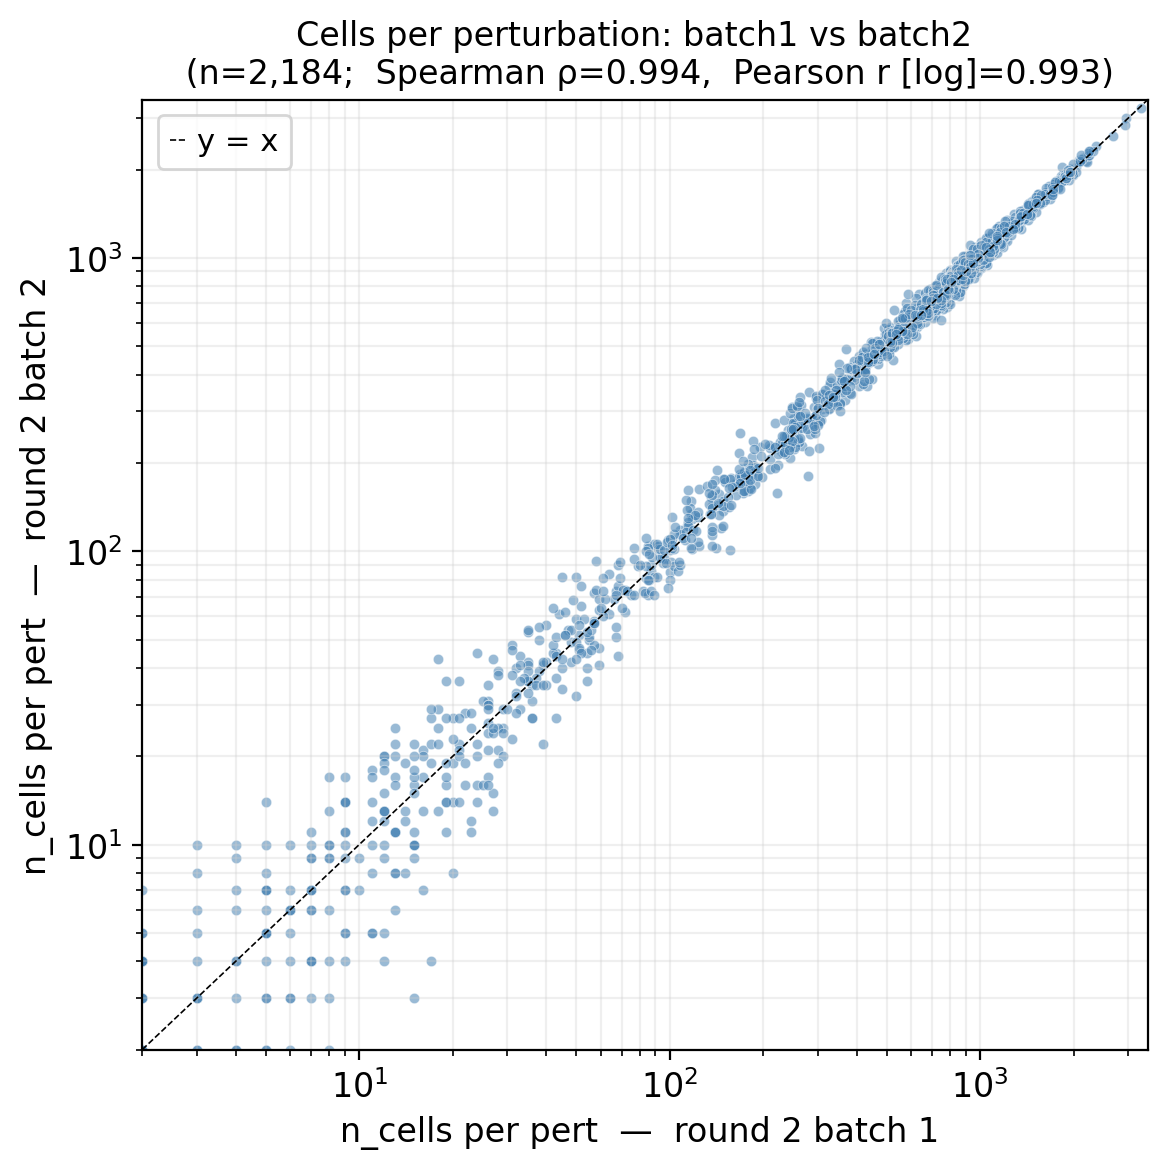

n1/n2 ratio summary  median=0.98  [5%=0.80, 95%=1.18]


In [19]:
import scipy.stats as st

lim_lo = max(1, int(min(n1.min(), n2.min())))
lim_hi = int(max(n1.max(), n2.max())) * 1.05

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(n1.values, n2.values, s=14, alpha=0.55,
            color="steelblue", edgecolor="white", linewidths=0.3)
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], "k--", lw=0.6, label="y = x")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(lim_lo, lim_hi); ax.set_ylim(lim_lo, lim_hi)
ax.set_xlabel(f"n_cells per pert  —  round 2 batch 1 ")
ax.set_ylabel(f"n_cells per pert  —  round 2 batch 2")
rho, _ = st.spearmanr(n1.values, n2.values)
r,   _ = st.pearsonr(np.log10(n1.values), np.log10(n2.values))
ax.set_title(f"Cells per perturbation: batch1 vs batch2  \n "
              f"(n={len(n1):,};  Spearman ρ={rho:.3f},  Pearson r [log]={r:.3f})")
ax.legend(loc="upper left")
ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

ratio = (n1 / n2).sort_values()
print(f"n1/n2 ratio summary  median={ratio.median():.2f}  "
      f"[5%={ratio.quantile(0.05):.2f}, 95%={ratio.quantile(0.95):.2f}]")

## 2. Volcano plots of the two DMSO replicates

For each replicate (`DMSO_round2`, `DMSO_round2_batch2`) we plot a
"full" volcano on a randomly-sampled set of **300 perturbations common
to both batches**:

- x = shrunken logFC from `PosteriorMean_matrix_<batch>.csv`
- y = $-\log_{10}(p)$ from `DATA/<batch>/<batch>_res.csv` (long-format
  `target × feature × p_value`; multiple source-file rows collapsed to the
  minimum p_value per (target, feature)).

No |logFC| threshold is applied. Points are coloured by p alone
(`p < P_THRESHOLD`) so the full effect-size distribution per
significance class is visible.

**Scale of the logFC axis.** The pipeline computes `mean_diff` as the
arithmetic mean of `adata.X` (perturbed cells) minus the arithmetic mean
of `adata.X` (non-targeting cells). `adata.X` was produced by
`sc.pp.log1p(adata)`, which is `np.log1p` → **natural log**. The ashr
posterior means inherit that scale: the x-axis is therefore in
**natural-log (ln) units**, not log2. To convert to log2, multiply by
`1/ln(2) ≈ 1.4427`.


sampled 300 perts (seed=0) from 2,184 common perts
[DMSO_round2] streaming DMSO_round2_res.csv for min p_value …
  [cache] reading DMSO_round2_minp.parquet


/tmp/ipykernel_2266956/1284897974.py:37: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  pm_long = pm_sub.stack(dropna=True).rename("logFC").reset_index()


[DMSO_round2_batch2] streaming DMSO_round2_batch2_res.csv for min p_value …
  [cache] reading DMSO_round2_batch2_minp.parquet


/tmp/ipykernel_2266956/1284897974.py:37: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  pm_long = pm_sub.stack(dropna=True).rename("logFC").reset_index()


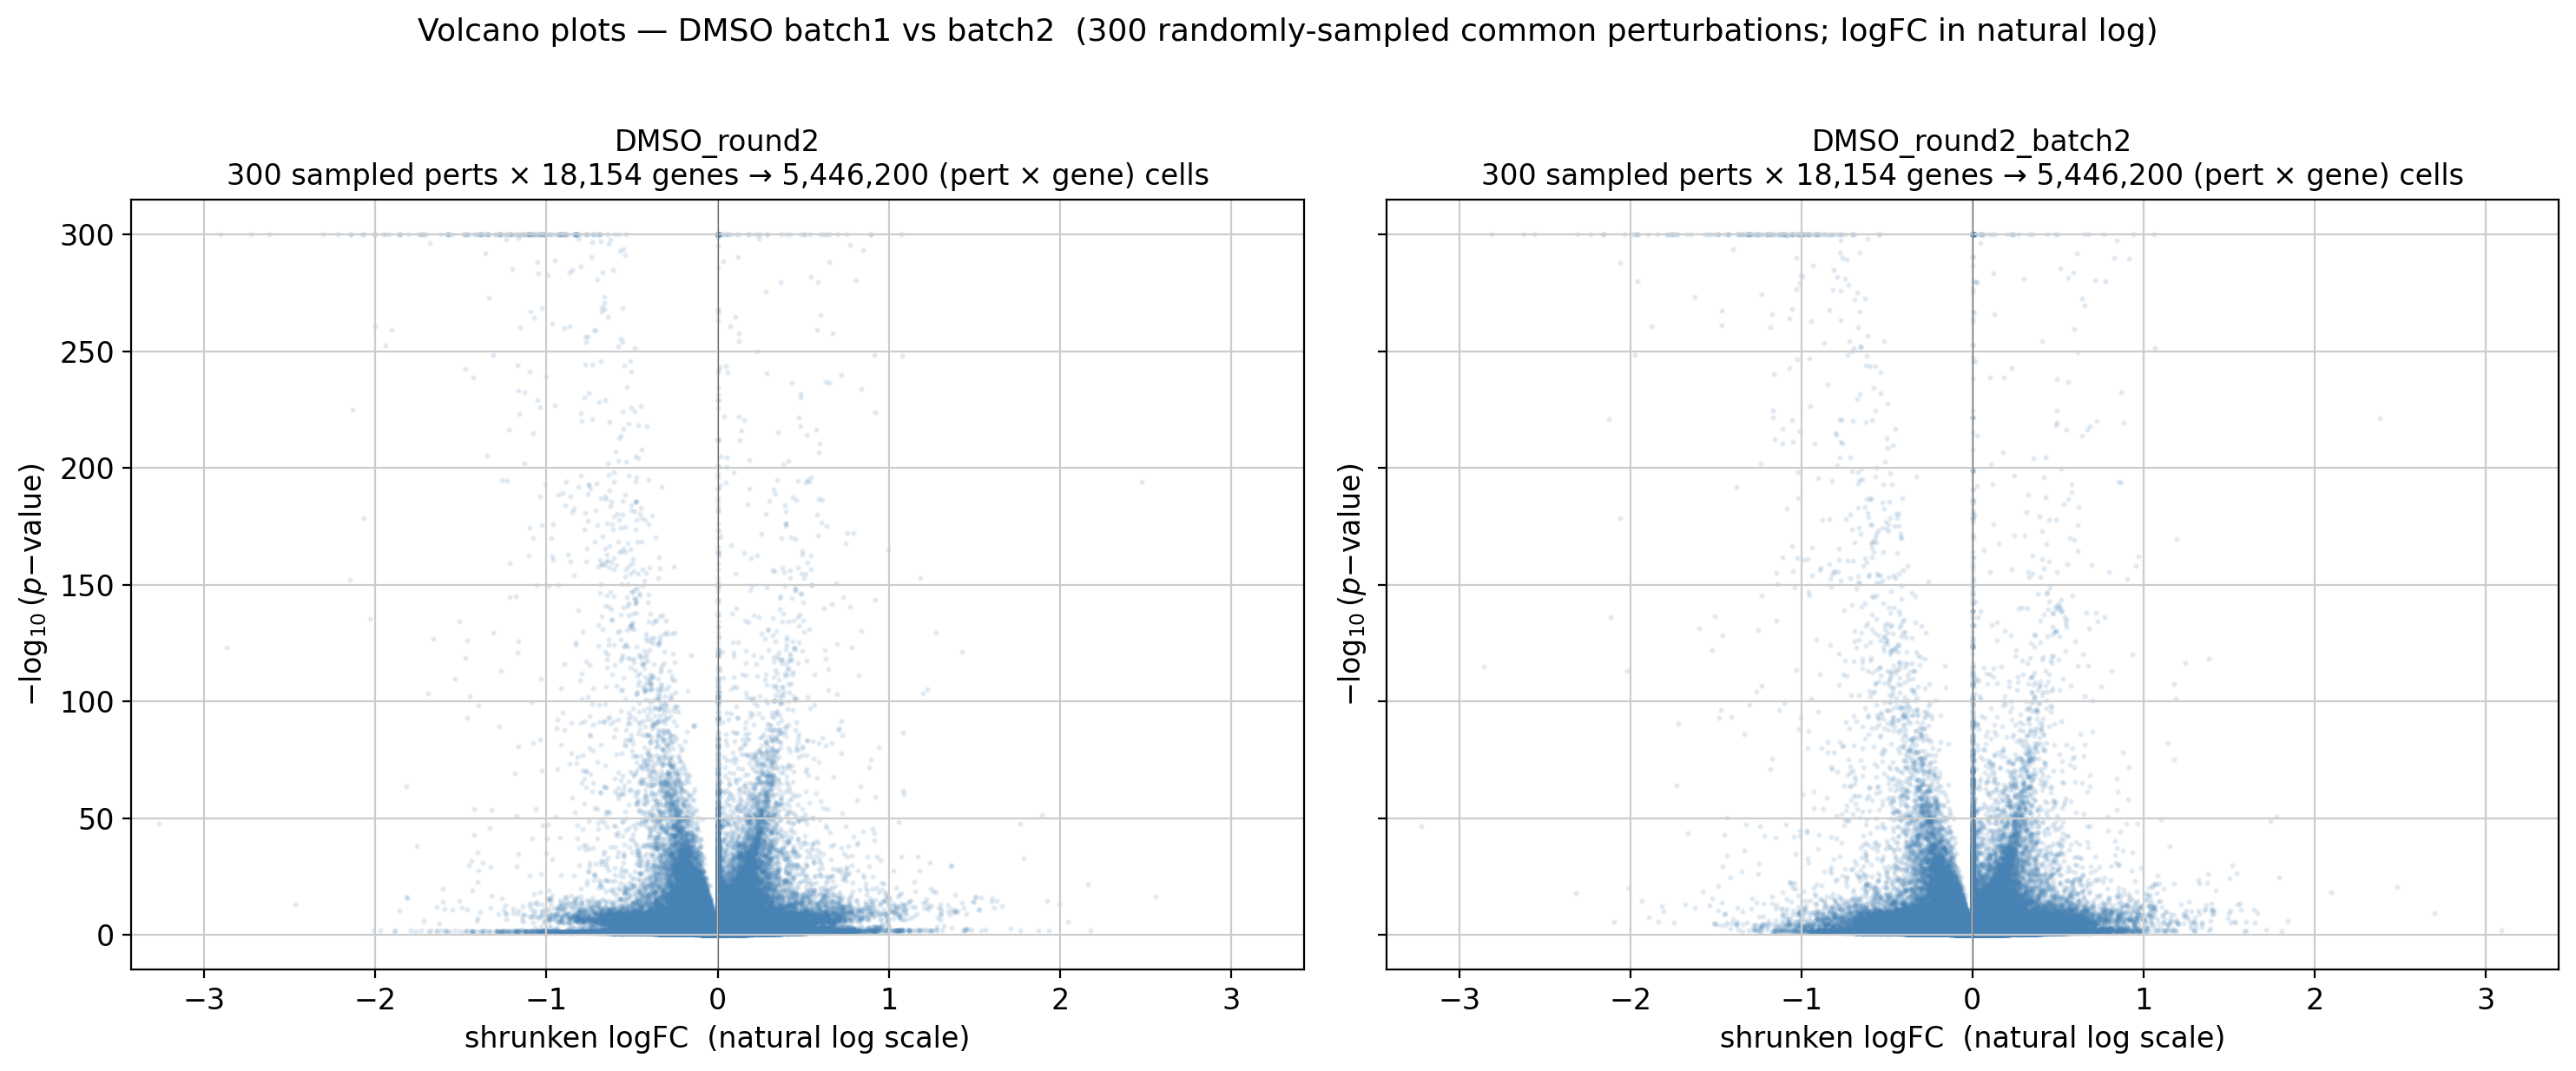

In [4]:
# Reset to the notebook's inline backend in case a prior import flipped it
%matplotlib inline
import matplotlib.pyplot as plt   # re-bind after backend switch

# Re-use the aggregation function from SRC/PythonScripts/GenerateVolcanoPlots.py
# (the path is already on sys.path via the imports cell above).
from GenerateVolcanoPlots import get_or_build_minp

DATA_DIR        = PROJ / "DATA"
VOLCANO_OUT_DIR = OUT_DIR / "volcano"
MINP_CACHE_DIR  = VOLCANO_OUT_DIR / "minp_cache"
VOLCANO_OUT_DIR.mkdir(parents=True, exist_ok=True)

N_SAMPLE_PERTS = 300
RNG_SEED = 0

# Pick 300 perturbations common to both batches' shrunken-logFC matrices.
# (`common_perts` from Section 1 already covers the intersection of all
#  four inputs — perts present in both posterior matrices and both raw
#  adatas; we sample from that set.)
rng = np.random.default_rng(RNG_SEED)
n_sample = min(N_SAMPLE_PERTS, len(common_perts))
sample_perts = sorted(rng.choice(common_perts, size=n_sample, replace=False))
print(f"sampled {len(sample_perts)} perts (seed={RNG_SEED}) from {len(common_perts):,} common perts")

def make_volcano(ax, batch_name, pm_df, *, refresh: bool = False):
    """Volcano for one DMSO batch on the provided axis.

    Uses every (pert, gene) cell for the `sample_perts` subset — no logFC
    threshold, no significance filtering on x-axis."""
    res_csv = DATA_DIR / batch_name / f"{batch_name}_res.csv"
    print(f"[{batch_name}] streaming {res_csv.name} for min p_value …", flush=True)
    minp = get_or_build_minp(res_csv, MINP_CACHE_DIR, refresh=refresh)

    # Long-format logFC for the sampled perts only
    pm_sub = pm_df.loc[sample_perts]
    pm_long = pm_sub.stack(dropna=True).rename("logFC").reset_index()
    pm_long.columns = ["target", "feature", "logFC"]

    # Inner join — only (target, feature) cells with both a logFC and a p_value
    df = pd.merge(pm_long, minp, on=["target", "feature"], how="inner")
    df["nlogp"] = -np.log10(np.clip(df["p_value"].values, 1e-300, 1.0))

    ax.scatter(df["logFC"], df["nlogp"],
                s=2, alpha=0.10, color="steelblue", rasterized=True)
    ax.axvline(0, color="black", lw=0.4, alpha=0.5)
    ax.set_xlabel("shrunken logFC  (natural log scale)")
    ax.set_ylabel(r"$-\log_{10}(p\mathrm{-value})$")
    ax.set_title(f"{batch_name}\n{n_sample} sampled perts × {len(df) // n_sample if n_sample else 0:,} genes "
                  f"\u2192 {len(df):,} (pert × gene) cells")
    return df


fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
df_b1 = make_volcano(axes[0], B1_NAME, b1)
df_b2 = make_volcano(axes[1], B2_NAME, b2)

# Symmetrize x-axis using the wider of the two batches' ranges
xlim = max(abs(df_b1["logFC"]).max(), abs(df_b2["logFC"]).max()) * 1.05
for ax in axes:
    ax.set_xlim(-xlim, xlim)

fig.suptitle(
    f"Volcano plots — DMSO batch1 vs batch2  "
    f"({n_sample} randomly-sampled common perturbations; logFC in natural log)",
    fontsize=13, y=1.02,
)
fig.tight_layout()
plt.show()


## 3. Jaccard at threshold — vectorized

In [5]:
def jaccard_per_pert_at_thresholds(B1, B2, thresholds, *, FDR1=None, FDR2=None,
                                   fdr_thr=0.05, signed=False):
    """Per-perturbation Jaccard of DE-gene sets at each |logFC| threshold.

    A gene is called **DE** for a perturbation in a given context iff

        |beta| >= tau   AND   FDR < fdr_thr

    The FDR gate is applied per context from `FDR1` / `FDR2` (aligned to
    `B1` / `B2`; NaN FDR -> not DE). If a context's FDR matrix is None, only the
    effect-size criterion |beta| >= tau is used.

    Parameters
    ----------
    B1, B2 : pd.DataFrame   (perturbation x gene) posterior-mean logFC.
    FDR1, FDR2 : pd.DataFrame | None   matching FDR matrices.
    fdr_thr : float, default 0.05   FDR significance cutoff.
    signed : bool, default False
        If True, a gene only counts in the intersection if it is DE in **both**
        contexts AND has the **same sign** of effect. Union = DE in either.

    Returns
    -------
    pd.DataFrame with columns
        perturbation, threshold, n_sig_b1, n_sig_b2, n_intersection,
        n_union, jaccard.
    """
    v1 = B1.values
    v2 = B2.values
    a1 = np.abs(v1)
    a2 = np.abs(v2)

    # Per-context FDR gate (NaN FDR -> not significant).
    if FDR1 is not None:
        f1 = FDR1.values
        ok1 = ~np.isnan(f1) & (f1 < fdr_thr)
    else:
        ok1 = np.ones_like(a1, dtype=bool)
    if FDR2 is not None:
        f2 = FDR2.values
        ok2 = ~np.isnan(f2) & (f2 < fdr_thr)
    else:
        ok2 = np.ones_like(a2, dtype=bool)

    perts = list(B1.index)
    rows = []

    for tau in thresholds:
        s1 = (a1 >= tau) & ok1          # DE in batch1: |logFC| >= tau AND FDR < fdr_thr
        s2 = (a2 >= tau) & ok2          # DE in batch2
        n_sig_b1 = s1.sum(axis=1)
        n_sig_b2 = s2.sum(axis=1)

        if signed:
            same_sign = np.sign(v1) == np.sign(v2)
            inter = (s1 & s2 & same_sign).sum(axis=1)
        else:
            inter = (s1 & s2).sum(axis=1)
        union = (s1 | s2).sum(axis=1)

        with np.errstate(divide='ignore', invalid='ignore'):
            jacc = np.where(union > 0, inter / union, np.nan)

        for i, p in enumerate(perts):
            rows.append({
                "perturbation":   p,
                "threshold":      float(tau),
                "n_sig_b1":       int(n_sig_b1[i]),
                "n_sig_b2":       int(n_sig_b2[i]),
                "n_intersection": int(inter[i]),
                "n_union":        int(union[i]),
                "jaccard":        float(jacc[i]) if np.isfinite(jacc[i]) else np.nan,
            })
    return pd.DataFrame(rows)

## 4. Compute the FDR-gated, sign-aware Jaccard curve

A sweep of thresholds, log-spaced from 0.01 to the 99th percentile of $|\beta|$
across both batches (plus $\tau=0$, where the curve is the pure-FDR overlap). A
gene is DE iff `FDR < FDR_THR` (=0.05) **and** $|\beta| \ge \tau$; `signed=True`
additionally requires the sign of $\beta$ to agree across batches.

In [6]:
# Log-spaced thresholds (the original setup) — 40 points from 0.01 to the
# 99th percentile of |β|, giving good resolution across the small-effect bulk
# and the long tail.
absmax = float(np.nanpercentile(np.abs(np.concatenate([b1.values.ravel(),
                                                        b2.values.ravel()])), 99))
thresholds = np.concatenate([[0.0],
                              np.logspace(np.log10(0.01), np.log10(max(absmax, 1.0)), 40)])
print(f"thresholds: {thresholds[0]:.4f} → {thresholds[-1]:.3f}  (n={len(thresholds)})")

jac_signed = jaccard_per_pert_at_thresholds(
    b1, b2, thresholds, FDR1=fdr_b1, FDR2=fdr_b2, fdr_thr=FDR_THR, signed=True)
jac_signed["n_cells_min"] = jac_signed["perturbation"].map(n_min.to_dict())
print(f"long table rows: {len(jac_signed):,}")
print(jac_signed.head().to_string(index=False))


thresholds: 0.0000 → 1.000  (n=41)
long table rows: 89,544
perturbation  threshold  n_sig_b1  n_sig_b2  n_intersection  n_union  jaccard  n_cells_min
        A1BG        0.0       138       124              14      248 0.056452         2089
        AASS        0.0       175       127              24      278 0.086331          659
       ABCB6        0.0       227       139              20      346 0.057803         1117
       ABCC5        0.0       149       122              17      254 0.066929          863
       ABCF1        0.0       131        98               1      227 0.004405          990


## 5. Group perturbations by cell count and plot

Default bins are quartiles of `min(n_cells_b1, n_cells_b2)`. Override
`bins`/`bin_labels` below if you want fixed cutoffs.


perturbations per bin:
n_cells_bin
2-50 cells         295
50-100 cells        85
100-200 cells      123
200-400 cells      167
400-800 cells      605
800-1600 cells     820
1600-3000 cells     88
  perturbations outside [2, 3000]: 1


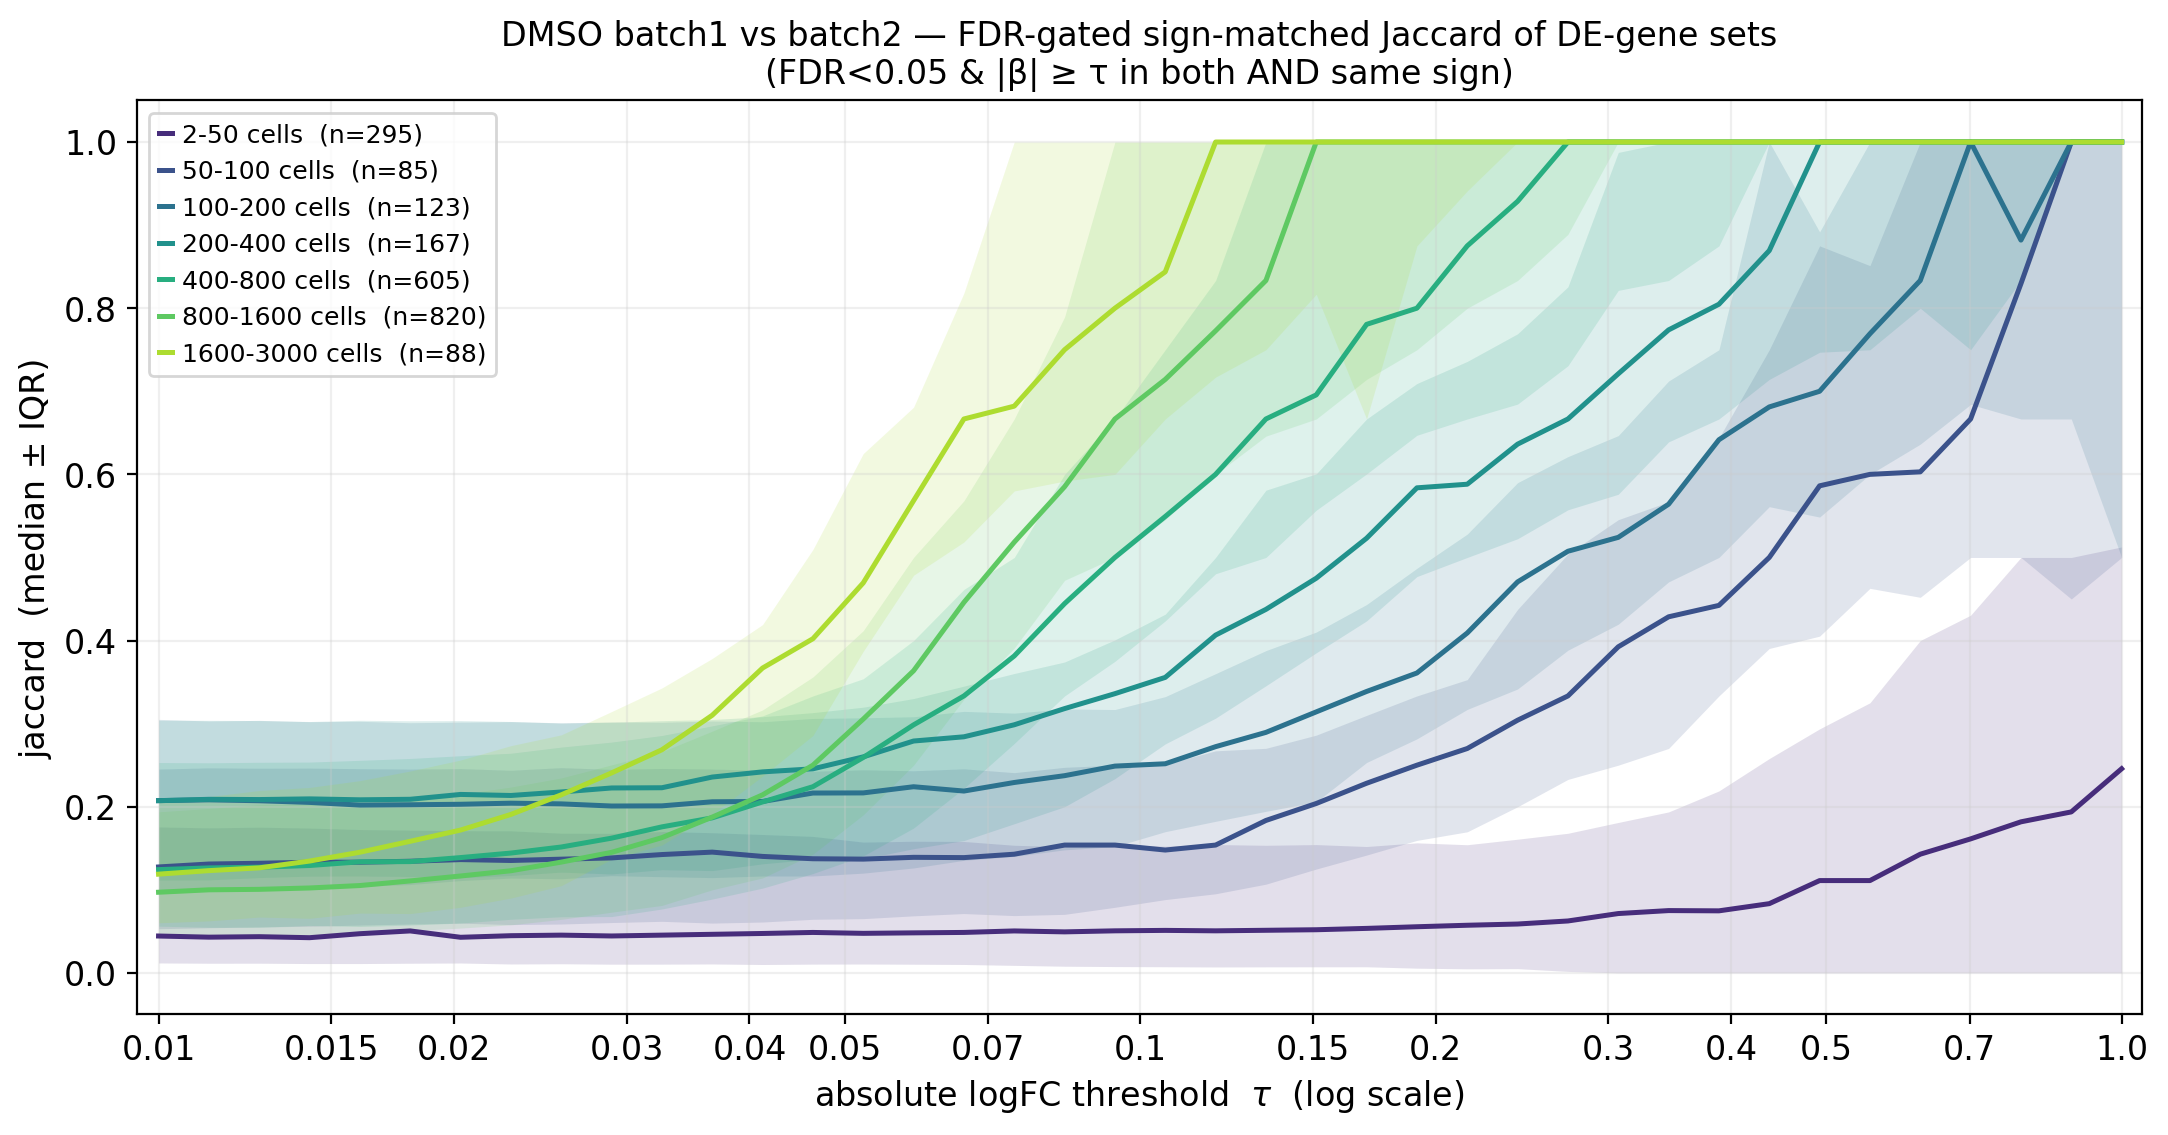

In [7]:
# ---- fixed-cutoff cell-count bins ----
bins = [2, 50, 100, 200, 400, 800, 1600, 3000]
bin_labels = [
    "2-50 cells",
    "50-100 cells",
    "100-200 cells",
    "200-400 cells",
    "400-800 cells",
    "800-1600 cells",
    "1600-3000 cells",
]
pert_bin = pd.cut(n_min, bins=bins, labels=bin_labels, include_lowest=True)
pert_bin.name = "n_cells_bin"
print("perturbations per bin:")
print(pert_bin.value_counts().reindex(bin_labels, fill_value=0).to_string())
print(f"  perturbations outside [{bins[0]}, {bins[-1]}]: "
      f"{int(pert_bin.isna().sum())}")

jac_signed["n_cells_bin"] = jac_signed["perturbation"].map(pert_bin.to_dict())

# A dense set of "round" tick positions on a log scale — restricted at draw
# time to the actual x-range. Gives many more value labels than matplotlib's
# default major ticks at decade boundaries.
_LOG_TICKS = np.array([
    0.005, 0.007,
    0.01,  0.015, 0.02, 0.03, 0.04, 0.05, 0.07,
    0.10,  0.15,  0.20, 0.30, 0.40, 0.50, 0.70,
    1.00,  1.50,  2.00, 3.00, 4.00, 5.00, 7.00,
    10.0,  15.0,  20.0,
])

def _fmt_tick(x: float) -> str:
    if x >= 10:
        return f"{x:.0f}"
    if x >= 1:
        return f"{x:.1f}"
    return f"{x:g}"


def plot_jaccard_vs_threshold(jac_signed, *, ax=None,
                                use_median=True, ci=(25, 75),
                                value_col="jaccard",
                                ylabel=None, title=None,
                                logy=False):
    """Line plot of a per-perturbation metric vs threshold.

    One curve per cell-count bin; band = IQR by default. Log-scale x-axis
    with explicit "round" ticks for easy reading.

    Parameters
    ----------
    value_col : str
        Column of `jac_signed` to aggregate / plot on the y-axis. Default
        is ``"jaccard"``; use e.g. ``"n_intersection"`` to plot raw counts.
    ylabel, title : str | None
        Override the auto-generated y-axis label / title.
    logy : bool
        Use a log y-axis (useful for ``n_intersection`` which can span
        several orders of magnitude).
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5.5))
    palette = sns.color_palette("viridis", n_colors=len(bin_labels))
    agg_centre = "median" if use_median else "mean"
    for color, lab in zip(palette, bin_labels):
        sub = jac_signed[jac_signed["n_cells_bin"] == lab]
        if sub.empty:
            continue
        sub_pos = sub[sub["threshold"] > 0]
        g = sub_pos.groupby("threshold")[value_col]
        centre = g.median() if use_median else g.mean()
        lo = g.quantile(ci[0] / 100)
        hi = g.quantile(ci[1] / 100)
        n = sub["perturbation"].nunique()
        ax.plot(centre.index, centre.values,
                color=color, lw=1.8,
                label=f'{lab}  (n={n})')
        ax.fill_between(centre.index, lo.values, hi.values,
                         color=color, alpha=0.15, linewidth=0)

    # Log-scale x-axis with explicit "round" ticks for easy reading.
    # τ = 0 is dropped from the curves since log(0) is undefined.
    x_lo = float(jac_signed.loc[jac_signed["threshold"] > 0, "threshold"].min())
    x_hi = float(jac_signed["threshold"].max())
    ax.set_xscale("log")
    ax.set_xlim(x_lo * 0.95, x_hi * 1.05)
    xticks = _LOG_TICKS[(_LOG_TICKS >= x_lo) & (_LOG_TICKS <= x_hi)]
    ax.set_xticks(xticks)
    ax.set_xticklabels([_fmt_tick(t) for t in xticks], rotation=0)
    ax.minorticks_off()

    ax.set_xlabel(r"absolute logFC threshold  $\tau$  (log scale)")
    ax.set_ylabel(ylabel if ylabel is not None
                  else f"{value_col}  ({agg_centre} \u00b1 IQR)")
    ax.set_title(title if title is not None
                  else "DMSO batch1 vs batch2 — agreement of significant-gene sets per perturbation")
    ax.legend(loc="upper left", fontsize=9, frameon=True)
    if logy:
        ax.set_yscale("log")
    ax.grid(alpha=0.3, which="major")
    return ax


fig, ax = plt.subplots(figsize=(11, 5.8))
plot_jaccard_vs_threshold(jac_signed, ax=ax)
ax.set_title("DMSO batch1 vs batch2 — FDR-gated sign-matched Jaccard of DE-gene sets\n"
             "(FDR<0.05 & |β| ≥ τ in both AND same sign)")
fig.tight_layout()
plt.show()


## 6. Number of DE / intersecting genes vs threshold (sign-matched)

Same axes and stratification as the Jaccard plot, but the y-axis shows raw
counts instead of the ratio — useful to see whether low-Jaccard regions are
driven by small set sizes (small denominator) vs genuinely poor agreement. A
gene is DE iff `FDR < 0.05` and $|\beta| \ge \tau$; the intersection is
sign-matched:

$$
\big|\{g : \mathrm{FDR}^{(1)}_{p,g}<0.05 \land \mathrm{FDR}^{(2)}_{p,g}<0.05 \land
|\beta^{(1)}_{p,g}| \ge \tau \land |\beta^{(2)}_{p,g}| \ge \tau \land
\mathrm{sign}(\beta^{(1)}_{p,g})=\mathrm{sign}(\beta^{(2)}_{p,g})\}\big|.
$$

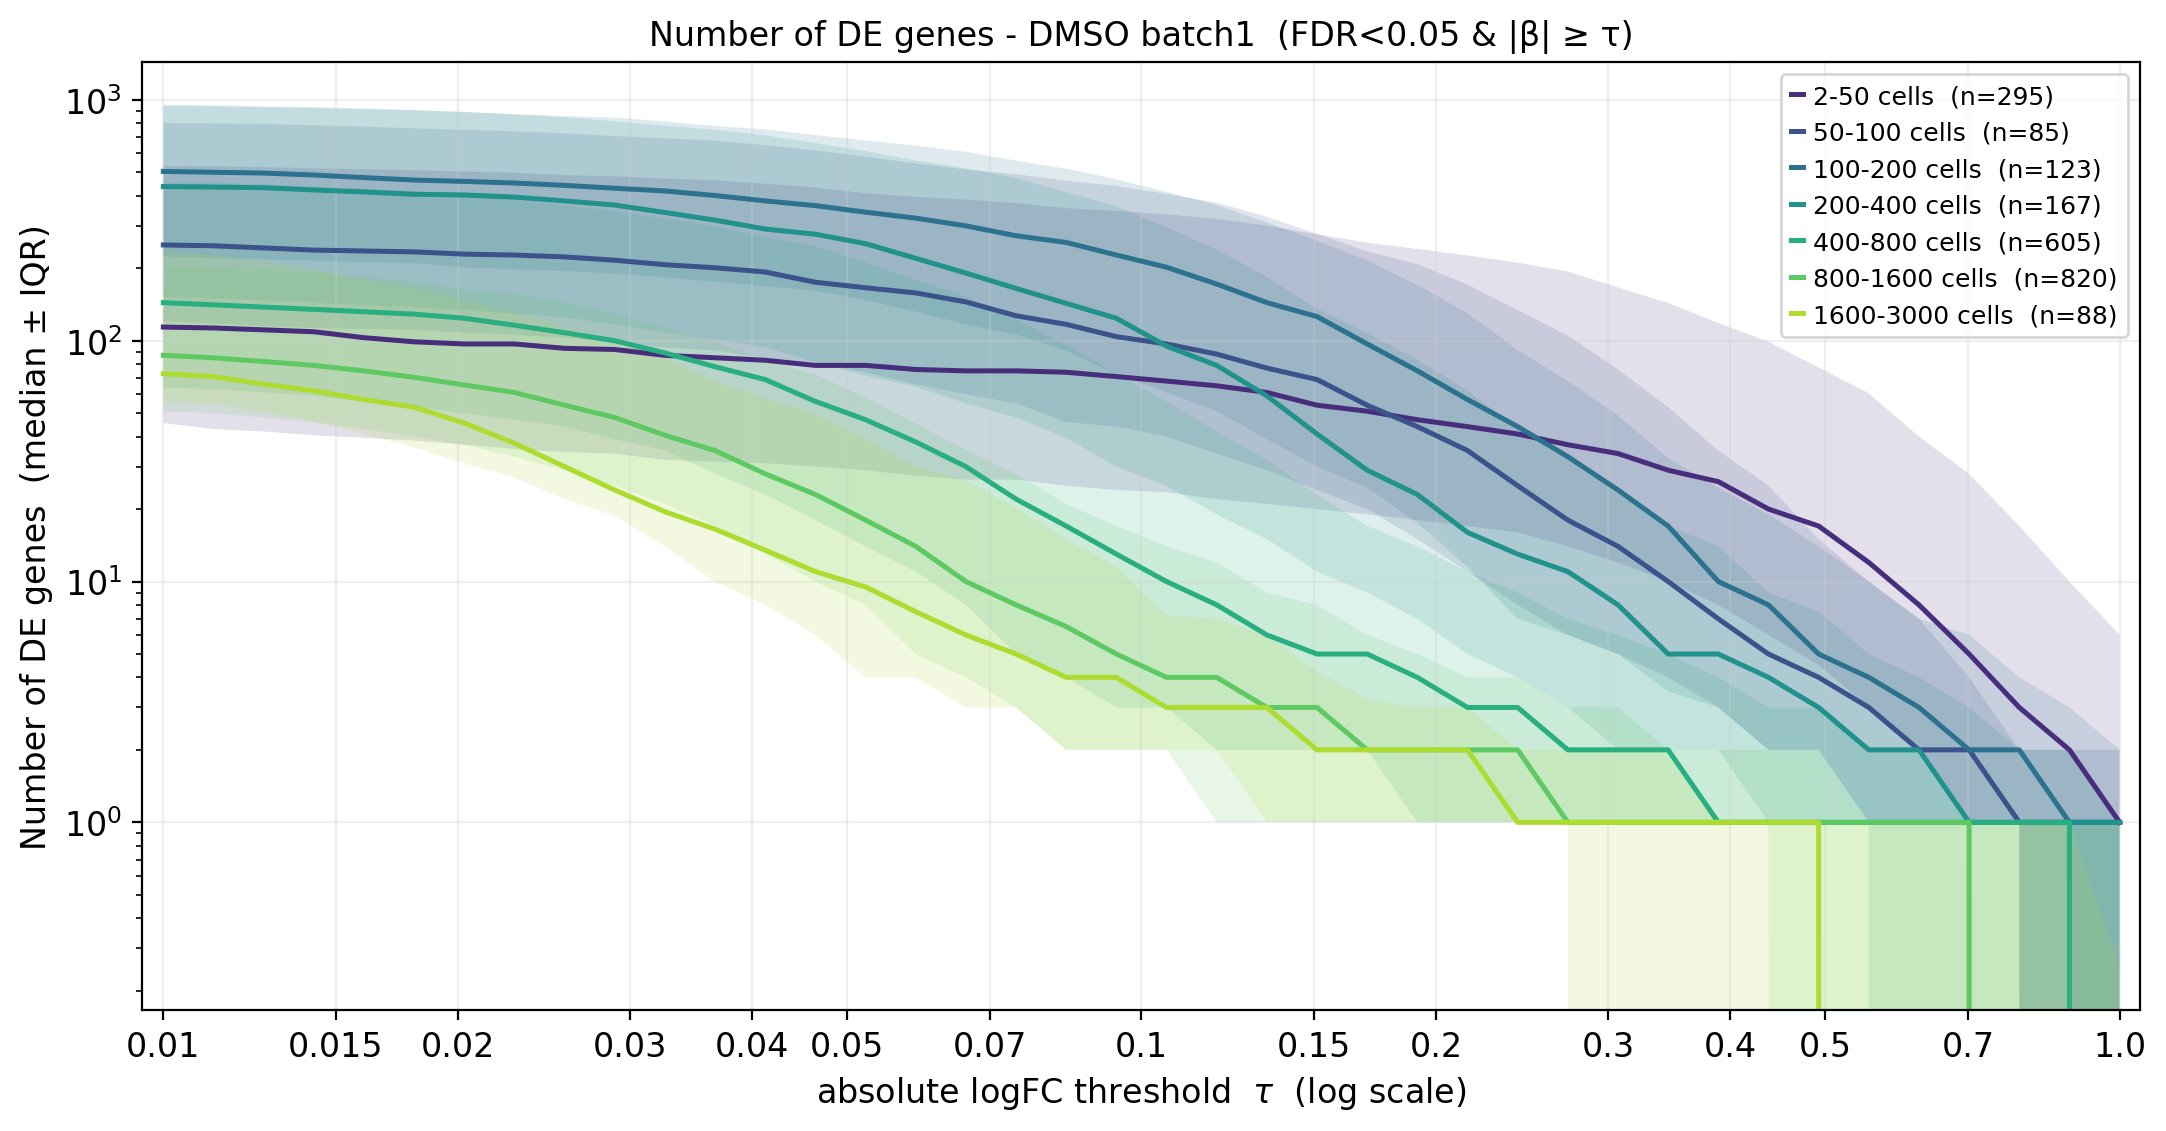

In [8]:
fig, ax = plt.subplots(figsize=(11, 5.8))
plot_jaccard_vs_threshold(
    jac_signed, ax=ax,
    value_col="n_sig_b1",
    ylabel="Number of DE genes  (median \u00b1 IQR)",
    title="Number of DE genes - DMSO batch1  (FDR<0.05 & |\u03b2| \u2265 \u03c4)",
    logy=True,
)
# Move the legend to the top-right corner for this figure.
ax.legend(loc="upper right", fontsize=9, frameon=True)
fig.tight_layout()
plt.show()


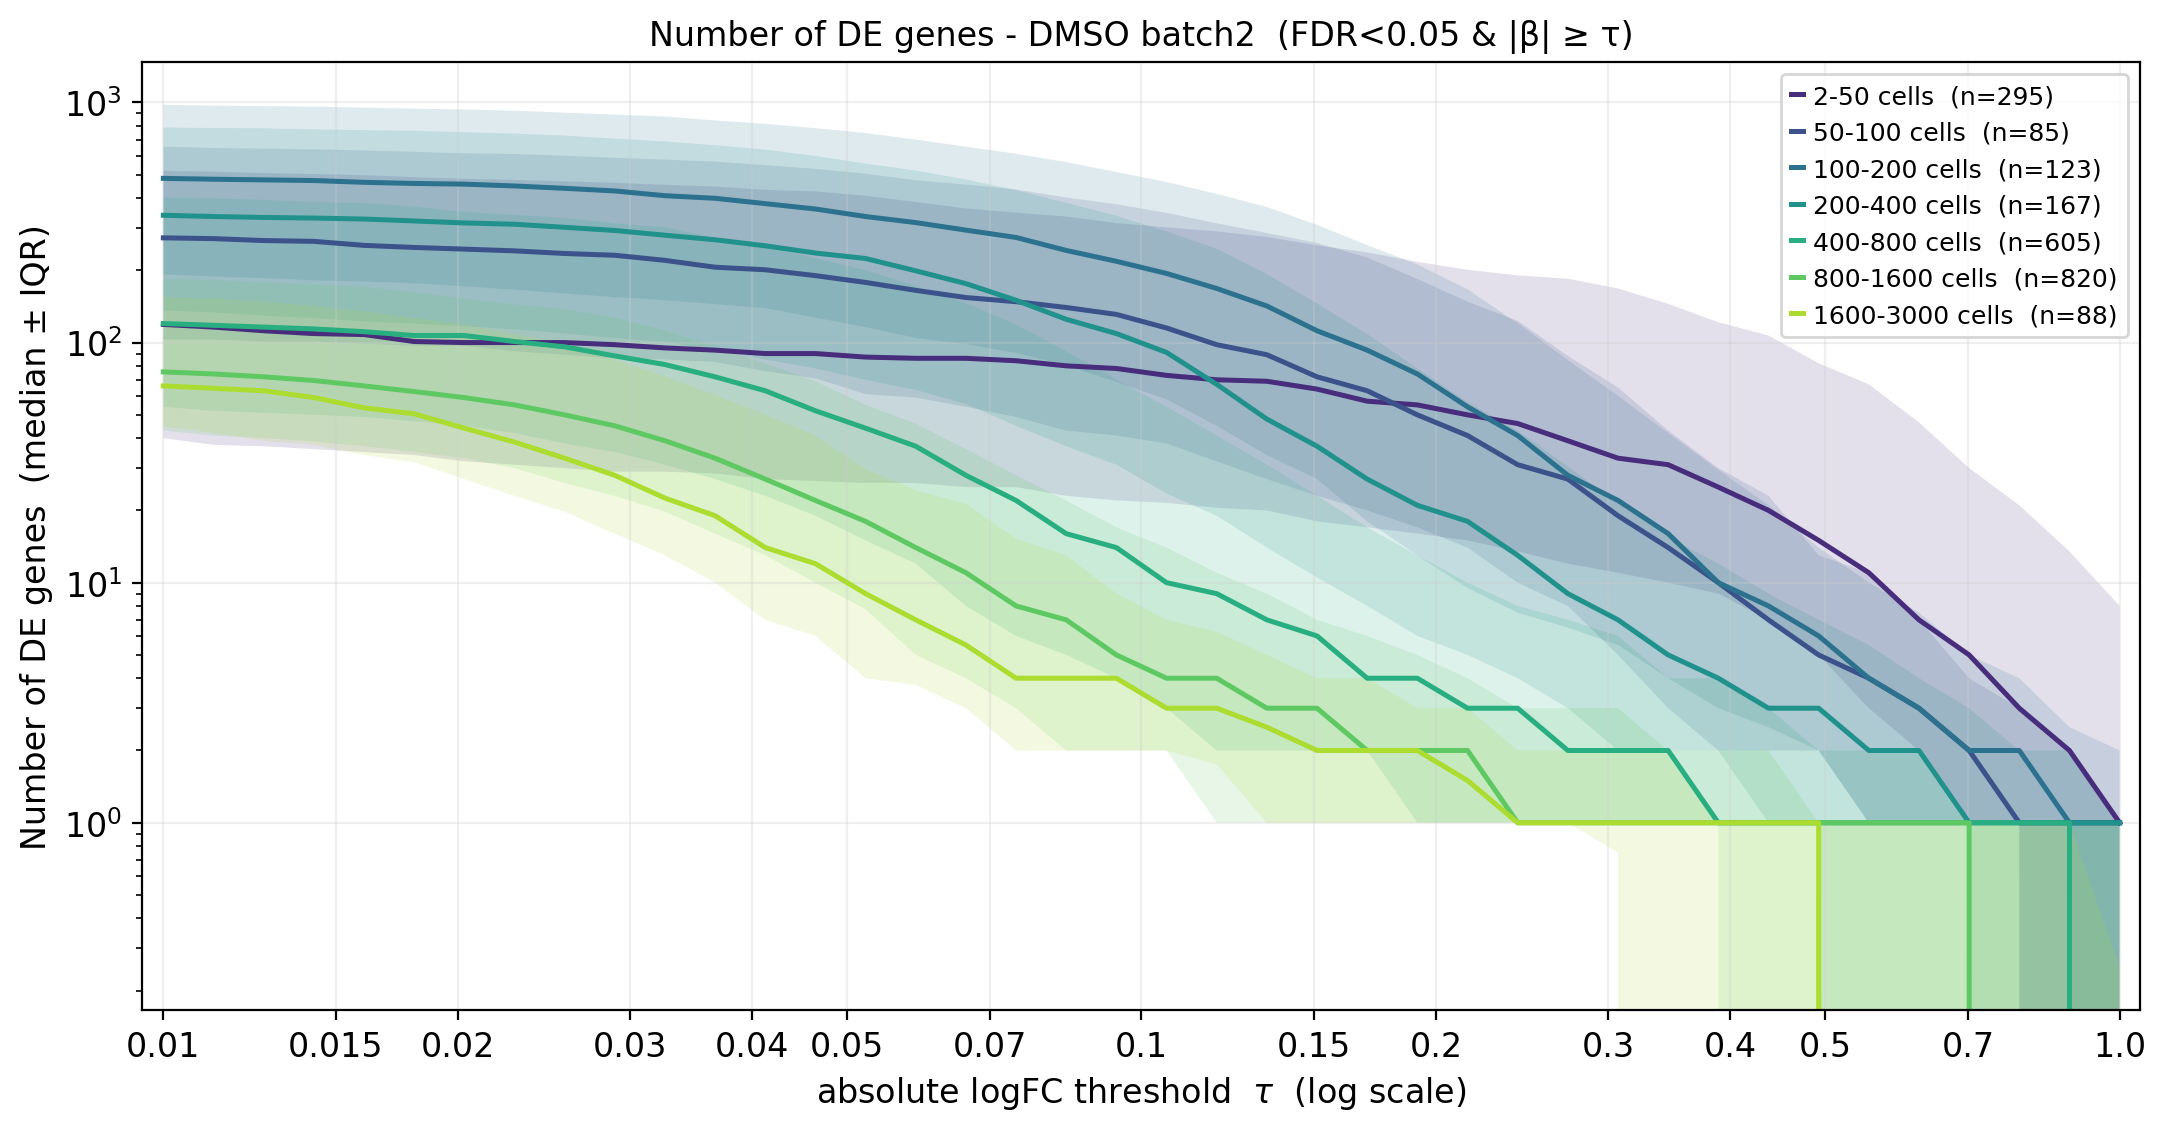

In [9]:
fig, ax = plt.subplots(figsize=(11, 5.8))
plot_jaccard_vs_threshold(
    jac_signed, ax=ax,
    value_col="n_sig_b2",
    ylabel="Number of DE genes  (median \u00b1 IQR)",
    title="Number of DE genes - DMSO batch2  (FDR<0.05 & |\u03b2| \u2265 \u03c4)",
    logy=True,
)
# Move the legend to the top-right corner for this figure.
ax.legend(loc="upper right", fontsize=9, frameon=True)
fig.tight_layout()
plt.show()


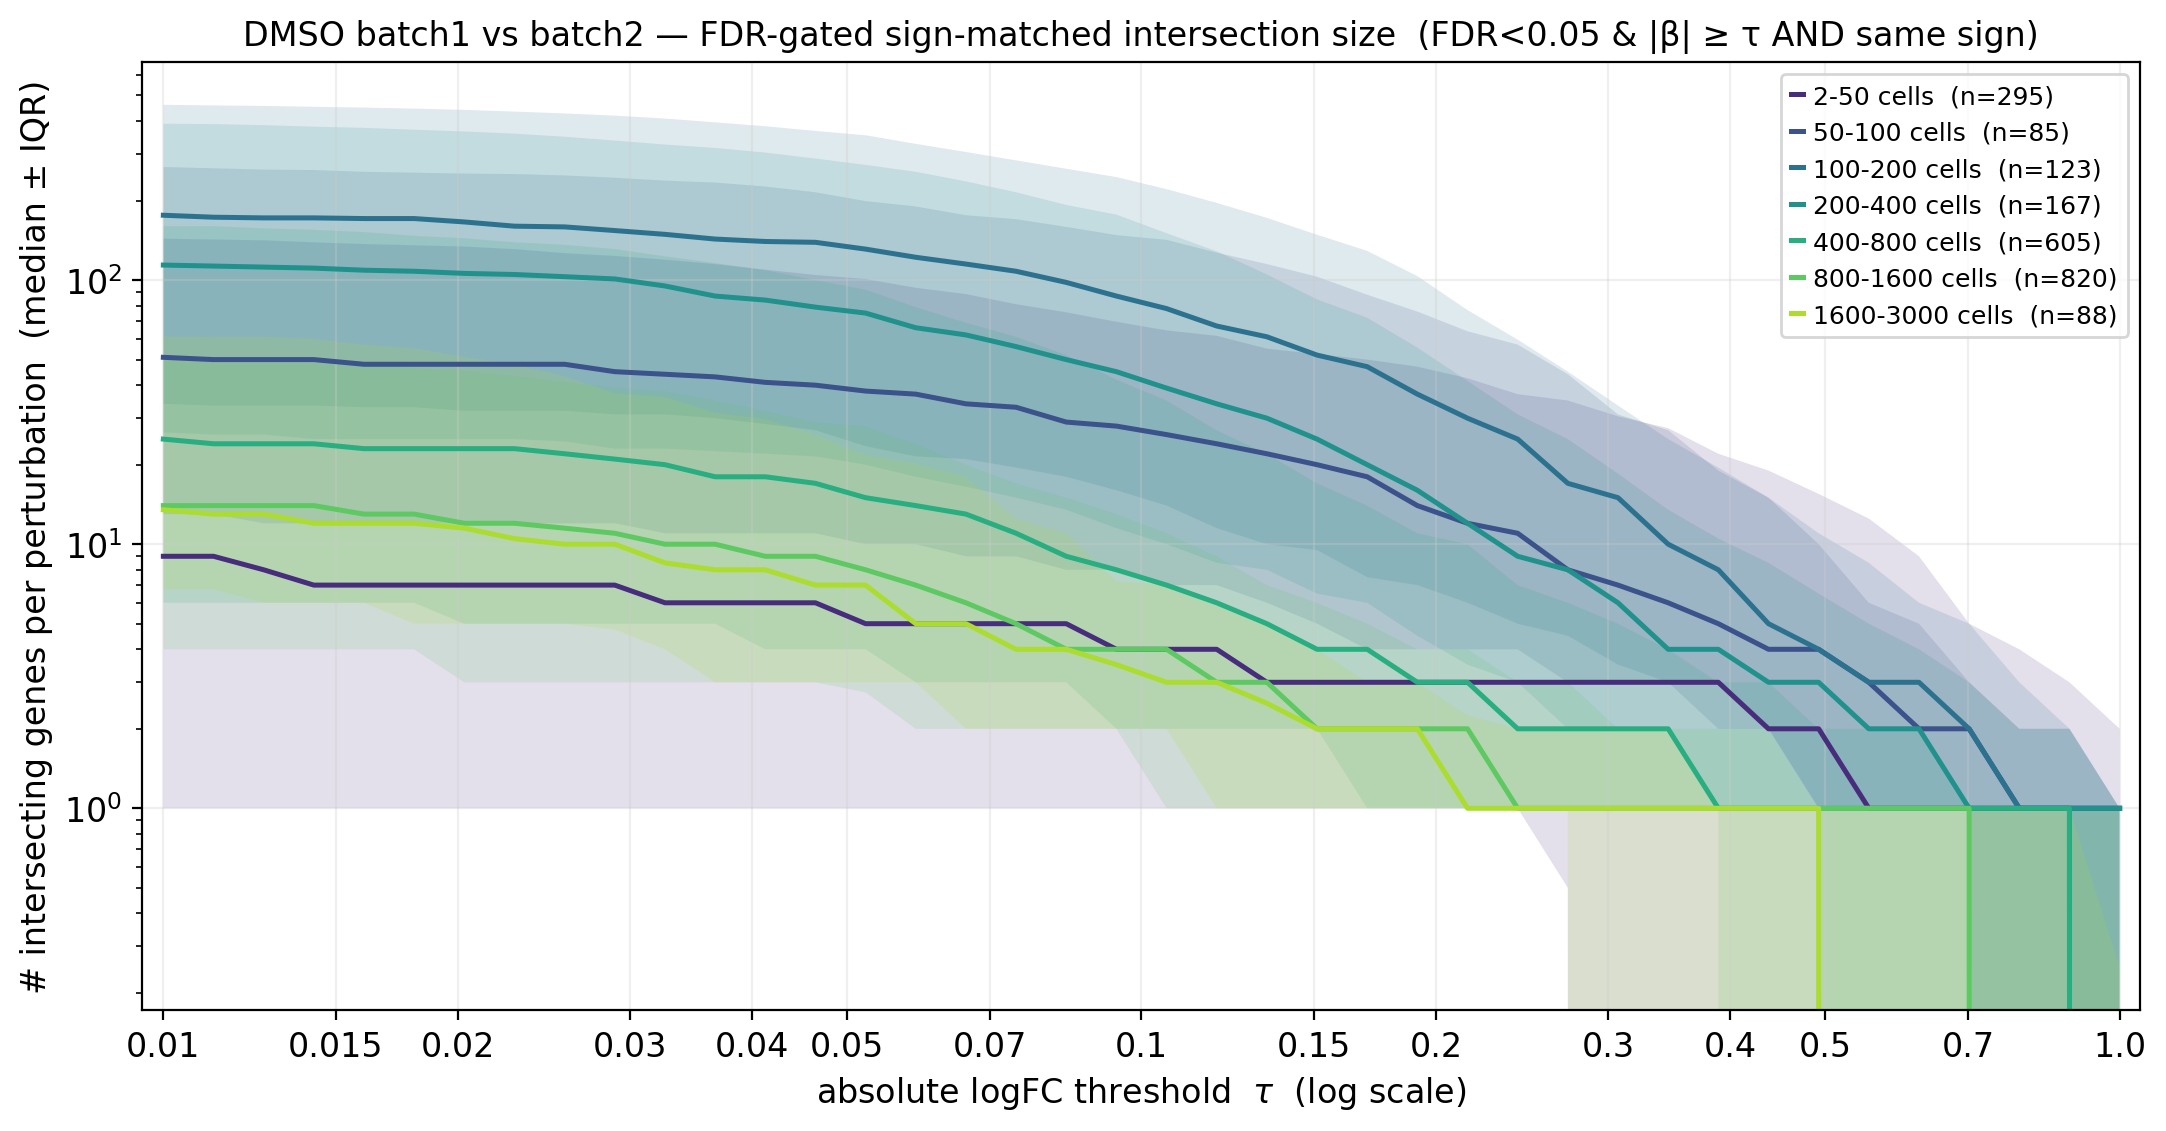

In [10]:
fig, ax = plt.subplots(figsize=(11, 5.8))
plot_jaccard_vs_threshold(
    jac_signed, ax=ax,
    value_col="n_intersection",
    ylabel="# intersecting genes per perturbation  (median \u00b1 IQR)",
    title="DMSO batch1 vs batch2 — FDR-gated sign-matched intersection size  (FDR<0.05 & |\u03b2| \u2265 \u03c4 AND same sign)",
    logy=True,
)
# Move the legend to the top-right corner for this figure.
ax.legend(loc="upper right", fontsize=9, frameon=True)
fig.tight_layout()
plt.show()


## 7. Save results

In [11]:
jac_signed.to_csv(OUT_DIR / "dmso_replicate_jaccard_long_signed.csv", index=False)
pert_bin.to_frame().assign(n_cells_min=n_min, n_cells_b1=n1, n_cells_b2=n2)\
    .to_csv(OUT_DIR / "pert_cell_counts.csv")

print("Saved:")
for p in OUT_DIR.iterdir():
    print(f"  {p.name}")


Saved:
  pert_cell_counts.csv
  dmso_replicate_jaccard_long_signed.csv
  dmso_replicate_jaccard_long_unsigned.csv
  dmso_replicate_jaccard_by_threshold.png
  volcano
  dmso_replicate_jaccard_signed_vs_unsigned.png


## 8. Extending to the drug contexts — is the DMSO-replicate concordance higher than DMSO-vs-drug?

Sections 3–6 measured, per perturbation, the **FDR-gated, sign-aware Jaccard**
between the two DMSO replicates (`DMSO_round2` vs `DMSO_round2_batch2`) as a
function of the |logFC| threshold $\tau$ — the *reproducibility floor*.

Here we run the **same FDR-gated, sign-aware sweep** between DMSO and **all 14
drug contexts**, and ask whether the replicate pair is **significantly more
concordant** than DMSO-vs-drug, and at which $\tau$ that gap is largest. (For a
quick run, set `N_DRUGS_SAMPLE` to an int — e.g. 5 — for a seeded random subset.)

**DE call (both sides):** `FDR < 0.05` **and** $|\beta| \ge \tau$, using each
context's own matrix from `FDR_matrices/`.

**Design (within-batch pairing).** Each drug is compared to *its own batch's*
DMSO, so the drop in concordance reflects the drug's remodelling of the
perturbation response, not batch variation:

* batch1 drugs (`AR-A014418, AZD4573, CHIR-98014, Lexibulin, PP121, Romidepsin, Stattic`) → vs `b1` (`DMSO_round2`)
* batch2 drugs (`Bisindolylmaleimide-I, DG-172, JTE-607, LDN-193189, LY2090314, NSC95397, VX-11e`) → vs `b2` (`DMSO_round2_batch2`)
* replicate baseline → `b1` vs `b2` (the `jac_signed` already computed above)

All comparisons are on the same `common_perts × common_genes` grid. **Test:** at
each $\tau$, a one-sided **paired Wilcoxon signed-rank** test
($J_\mathrm{replicate} > J_\mathrm{drug}$) across matched perturbations, per drug
and pooled.

In [22]:
# ---- per-drug SIGN-AWARE, FDR-gated Jaccard sweep, reusing the replicate machinery
# Runs on a RANDOM SUBSET of N_DRUGS_SAMPLE drug contexts (seeded). Set
# N_DRUGS_SAMPLE = len(ALL_DRUGS) to use all 14. DE iff FDR < FDR_THR AND |logFC| >= tau.
import scipy.stats as st

BATCH1_DRUGS = ["AR-A014418", "AZD4573", "CHIR-98014", "Lexibulin",
                "PP121", "Romidepsin", "Stattic"]
BATCH2_DRUGS = ["Bisindolylmaleimide-I", "DG-172", "JTE-607", "LDN-193189",
                "LY2090314", "NSC95397", "VX-11e"]
ALL_DRUGS = BATCH1_DRUGS + BATCH2_DRUGS
BATCH_OF  = {**{d: "batch1" for d in BATCH1_DRUGS},
             **{d: "batch2" for d in BATCH2_DRUGS}}

# Use ALL drug contexts by default (each compared to its OWN batch's DMSO via
# DMSO_REF[BATCH_OF[drug]] / FDR_REF[BATCH_OF[drug]]). For a quick run, set
# N_DRUGS_SAMPLE to an int (e.g. 5) to draw a seeded random subset instead.
N_DRUGS_SAMPLE = len(ALL_DRUGS)
RANDOM_SEED    = 0
if N_DRUGS_SAMPLE >= len(ALL_DRUGS):
    DRUGS = sorted(ALL_DRUGS)
    print(f"using ALL {len(DRUGS)} drug contexts (within-batch DMSO pairing): {DRUGS}")
else:
    _rng  = np.random.default_rng(RANDOM_SEED)
    DRUGS = sorted(_rng.choice(ALL_DRUGS, size=N_DRUGS_SAMPLE, replace=False).tolist())
    print(f"randomly selected {len(DRUGS)} / {len(ALL_DRUGS)} drug contexts "
          f"(seed={RANDOM_SEED}): {DRUGS}")

DMSO_REF = {"batch1": b1, "batch2": b2}         # within-batch DMSO logFC, common grid
FDR_REF  = {"batch1": fdr_b1, "batch2": fdr_b2}  # within-batch DMSO FDR,  common grid

OUT_DIR2 = PROJ / "Notes" / "dmso_vs_drug_concordance"
OUT_DIR2.mkdir(parents=True, exist_ok=True)


def drug_jaccard_long(drug):
    """Per-(pert, tau) SIGN-AWARE, FDR-gated Jaccard between the drug's batch
    DMSO and the drug. DE iff FDR < FDR_THR AND |logFC| >= tau, same sign."""
    ref     = DMSO_REF[BATCH_OF[drug]]
    fdr_ref = FDR_REF[BATCH_OF[drug]]
    d     = pd.read_csv(PM_DIR  / f"PosteriorMean_matrix_{drug}.csv", index_col=0)
    fdr_d = pd.read_csv(FDR_DIR / f"{drug}_FDRs.csv",                 index_col=0)
    perts = [p for p in ref.index   if p in d.index   and p in fdr_d.index]
    genes = [g for g in ref.columns if g in d.columns and g in fdr_d.columns]
    jl = jaccard_per_pert_at_thresholds(
        ref.loc[perts, genes], d.loc[perts, genes], thresholds,
        FDR1=fdr_ref.loc[perts, genes], FDR2=fdr_d.loc[perts, genes],
        fdr_thr=FDR_THR, signed=True)
    jl["n_cells_min"] = jl["perturbation"].map(n_min.to_dict())
    jl["drug"]  = drug
    jl["batch"] = BATCH_OF[drug]
    return jl


drug_long = {d: drug_jaccard_long(d) for d in DRUGS}
print(f"computed FDR-gated sign-aware per-drug Jaccard for {len(DRUGS)} drugs "
      f"(FDR<{FDR_THR}; {len(thresholds)} thresholds each)")

using ALL 14 drug contexts (within-batch DMSO pairing): ['AR-A014418', 'AZD4573', 'Bisindolylmaleimide-I', 'CHIR-98014', 'DG-172', 'JTE-607', 'LDN-193189', 'LY2090314', 'Lexibulin', 'NSC95397', 'PP121', 'Romidepsin', 'Stattic', 'VX-11e']
computed FDR-gated sign-aware per-drug Jaccard for 14 drugs (FDR<0.1; 41 thresholds each)


In [23]:
# ---- paired Wilcoxon (J_replicate > J_drug) per tau, per drug + pooled -------
def _bh(p):
    """Benjamini-Hochberg adjusted p-values."""
    p = np.asarray(p, float); n = p.size; o = np.argsort(p)
    r = p[o] * n / (np.arange(n) + 1)
    r = np.minimum.accumulate(r[::-1])[::-1]
    out = np.empty(n); out[o] = np.clip(r, 0, 1)
    return out


def paired_wilcoxon_greater(x, y):
    """One-sided paired signed-rank: H1 = x > y. -> (p, n, median_diff, frac_x>y)."""
    ok = np.isfinite(x) & np.isfinite(y); x, y = x[ok], y[ok]; n = int(ok.sum())
    if n == 0:
        return np.nan, 0, np.nan, np.nan
    d = x - y; md = float(np.median(d)); fg = float(np.mean(d > 0))
    if np.count_nonzero(d) == 0:
        return np.nan, n, md, fg
    try:
        _, p = st.wilcoxon(x, y, alternative="greater")
    except ValueError:
        p = np.nan
    return float(p), n, md, fg


def run_significance(rep_long, drug_longs):
    rep_w  = rep_long.pivot(index="perturbation", columns="threshold", values="jaccard")
    drug_w = {d: dl.pivot(index="perturbation", columns="threshold", values="jaccard")
              for d, dl in drug_longs.items()}
    taus = list(rep_w.columns)
    rows, pooled = [], {t: ([], []) for t in taus}
    for d, dw in drug_w.items():
        common = rep_w.index.intersection(dw.index)
        for t in taus:
            xr = rep_w.loc[common, t].values
            yd = dw.loc[common, t].values
            p, nn, mdif, fg = paired_wilcoxon_greater(xr, yd)
            rows.append(dict(drug=d, threshold=t, n_pairs=nn,
                             median_J_rep=float(np.nanmedian(xr)) if nn else np.nan,
                             median_J_drug=float(np.nanmedian(yd)) if nn else np.nan,
                             median_diff=mdif, frac_rep_greater=fg, p_value=p))
            ok = np.isfinite(xr) & np.isfinite(yd)
            pooled[t][0].append(xr[ok]); pooled[t][1].append(yd[ok])
    for t in taus:
        xr = np.concatenate(pooled[t][0]); yd = np.concatenate(pooled[t][1])
        p, nn, mdif, fg = paired_wilcoxon_greater(xr, yd)
        rows.append(dict(drug="POOLED", threshold=t, n_pairs=nn,
                         median_J_rep=float(np.nanmedian(xr)),
                         median_J_drug=float(np.nanmedian(yd)),
                         median_diff=mdif, frac_rep_greater=fg, p_value=p))
    sig = pd.DataFrame(rows)
    fin = sig["p_value"].notna(); sig["p_adj_bh"] = np.nan
    sig.loc[fin, "p_adj_bh"] = _bh(sig.loc[fin, "p_value"].values)
    return sig


sig = run_significance(jac_signed, drug_long)
sig.to_csv(OUT_DIR2 / "significance_signed.csv", index=False)
print("POOLED, sign-aware — replicate vs all-sampled-drugs concordance by threshold:")
cols = ["threshold", "median_J_rep", "median_J_drug", "median_diff",
        "frac_rep_greater", "p_adj_bh"]
print(sig[sig.drug == "POOLED"][cols]
      .to_string(index=False, float_format=lambda x: f"{x:.4g}"))

POOLED, sign-aware — replicate vs all-sampled-drugs concordance by threshold:
 threshold  median_J_rep  median_J_drug  median_diff  frac_rep_greater  p_adj_bh
         0       0.06787        0.05213      0.01183            0.7607         0
      0.01        0.1149         0.0782      0.02217            0.7913         0
   0.01125        0.1163        0.07937      0.02215             0.789         0
   0.01266         0.118        0.08065      0.02225            0.7867         0
   0.01425          0.12        0.08247      0.02237            0.7809         0
   0.01604        0.1226        0.08475      0.02248            0.7757         0
   0.01805         0.125        0.08709      0.02267            0.7684         0
   0.02031        0.1281        0.09091      0.02263            0.7594         0
   0.02285        0.1324        0.09574      0.02288            0.7467         0
   0.02572        0.1408         0.1016      0.02339             0.737         0
   0.02894        0.1507       

In [24]:
# ---- crossover / peak-separation summary per drug ---------------------------
# NB: with thousands of matched pairs the Wilcoxon test is significant at nearly
# every tau > 0, so the p-value "crossover" is not the discriminating quantity --
# the EFFECT SIZE (median J_rep - J_drug = separation) is. We report both.
def crossover_summary(sig, alpha=0.05):
    rows = []
    for drug, sub in sig.groupby("drug"):
        sub  = sub[sub.threshold > 0].sort_values("threshold")
        taus = sub.threshold.values
        padj = sub.p_adj_bh.values
        mdif = sub.median_diff.values
        sm   = padj < alpha
        suffix = np.array([sm[i:].all() for i in range(len(sm))])
        stable = float(taus[np.argmax(suffix)]) if suffix.any() else np.nan
        first  = float(taus[np.argmax(sm)]) if sm.any() else np.nan
        pool   = np.where(sm)[0] if sm.any() else np.arange(len(taus))
        pk     = pool[np.nanargmax(mdif[pool])]
        rows.append(dict(drug=drug, first_significant_tau=first,
                         stable_crossover_tau=stable,
                         peak_separation_tau=float(taus[pk]),
                         peak_median_diff=float(mdif[pk]),
                         peak_median_J_rep=float(sub.median_J_rep.values[pk]),
                         peak_median_J_drug=float(sub.median_J_drug.values[pk]),
                         peak_frac_rep_greater=float(sub.frac_rep_greater.values[pk]),
                         n_significant_taus=int(sm.sum()), n_taus=int(len(taus))))
    return pd.DataFrame(rows)


summary = crossover_summary(sig)
summary.to_csv(OUT_DIR2 / "crossover_summary.csv", index=False)
print(f"wrote {OUT_DIR2/'crossover_summary.csv'}")
# ranked by how strongly each sampled drug diverges from DMSO (peak separation)
summary.sort_values("peak_median_diff", ascending=False).reset_index(drop=True)

wrote /home/beraslan/Projects/ChemoGeneticScreens/Notes/dmso_vs_drug_concordance/crossover_summary.csv


,drug,first_significant_tau,stable_crossover_tau,peak_separation_tau,peak_median_diff,peak_median_J_rep,peak_median_J_drug,peak_frac_rep_greater,n_significant_taus,n_taus
0,CHIR-98014,0.01,0.010000,0.345511,0.375000,1.000000,0.285714,0.718472,40,40
1,LY2090314,0.01,0.010000,0.215443,0.351713,0.777778,0.250000,0.771990,40,40
2,VX-11e,0.01,0.010000,0.119378,0.166667,0.571429,0.257143,0.743554,40,40
3,JTE-607,0.01,0.010000,0.170125,0.139510,0.692308,0.428571,0.656027,40,40
4,AR-A014418,0.01,0.010000,0.151178,0.069137,0.666667,0.500000,0.616004,40,40
5,POOLED,0.01,0.010000,0.106082,0.049261,0.510000,0.376636,0.627627,40,40
6,LDN-193189,0.01,0.010000,0.094267,0.048611,0.500000,0.363636,0.636149,40,40
7,DG-172,0.01,0.010000,0.094267,0.040000,0.493457,0.397638,0.619580,40,40
8,PP121,0.01,0.010000,0.083768,0.031751,0.428571,0.345982,0.611732,40,40
9,Romidepsin,0.01,0.010000,0.074438,0.025783,0.375370,0.333333,0.609541,40,40


### 8a. Replicate baseline (bold black) vs each drug — Jaccard *and* intersection size

Two views of the same FDR-gated, sign-aware overlap, per $\tau$, median (line) with the 25–75% IQR shaded, across
perturbations. The DMSO replicate is the *upper envelope* in both. Solid =
batch1 drugs (vs `DMSO_round2`), dashed = batch2 (vs `DMSO_round2_batch2`).

1. **Jaccard similarity** $|A\cap B| / |A\cup B|$ — normalised concordance.
2. **Intersection size** $|A\cap B|$ — the raw number of sign-matched
   co-significant genes per perturbation (log y), as in the DMSO-replicate plot
   in Section 6. A gene is in $A\cap B$ iff it is DE (`FDR<0.05` & $|\beta|\ge\tau$)
   in **both** contexts with the **same sign**.

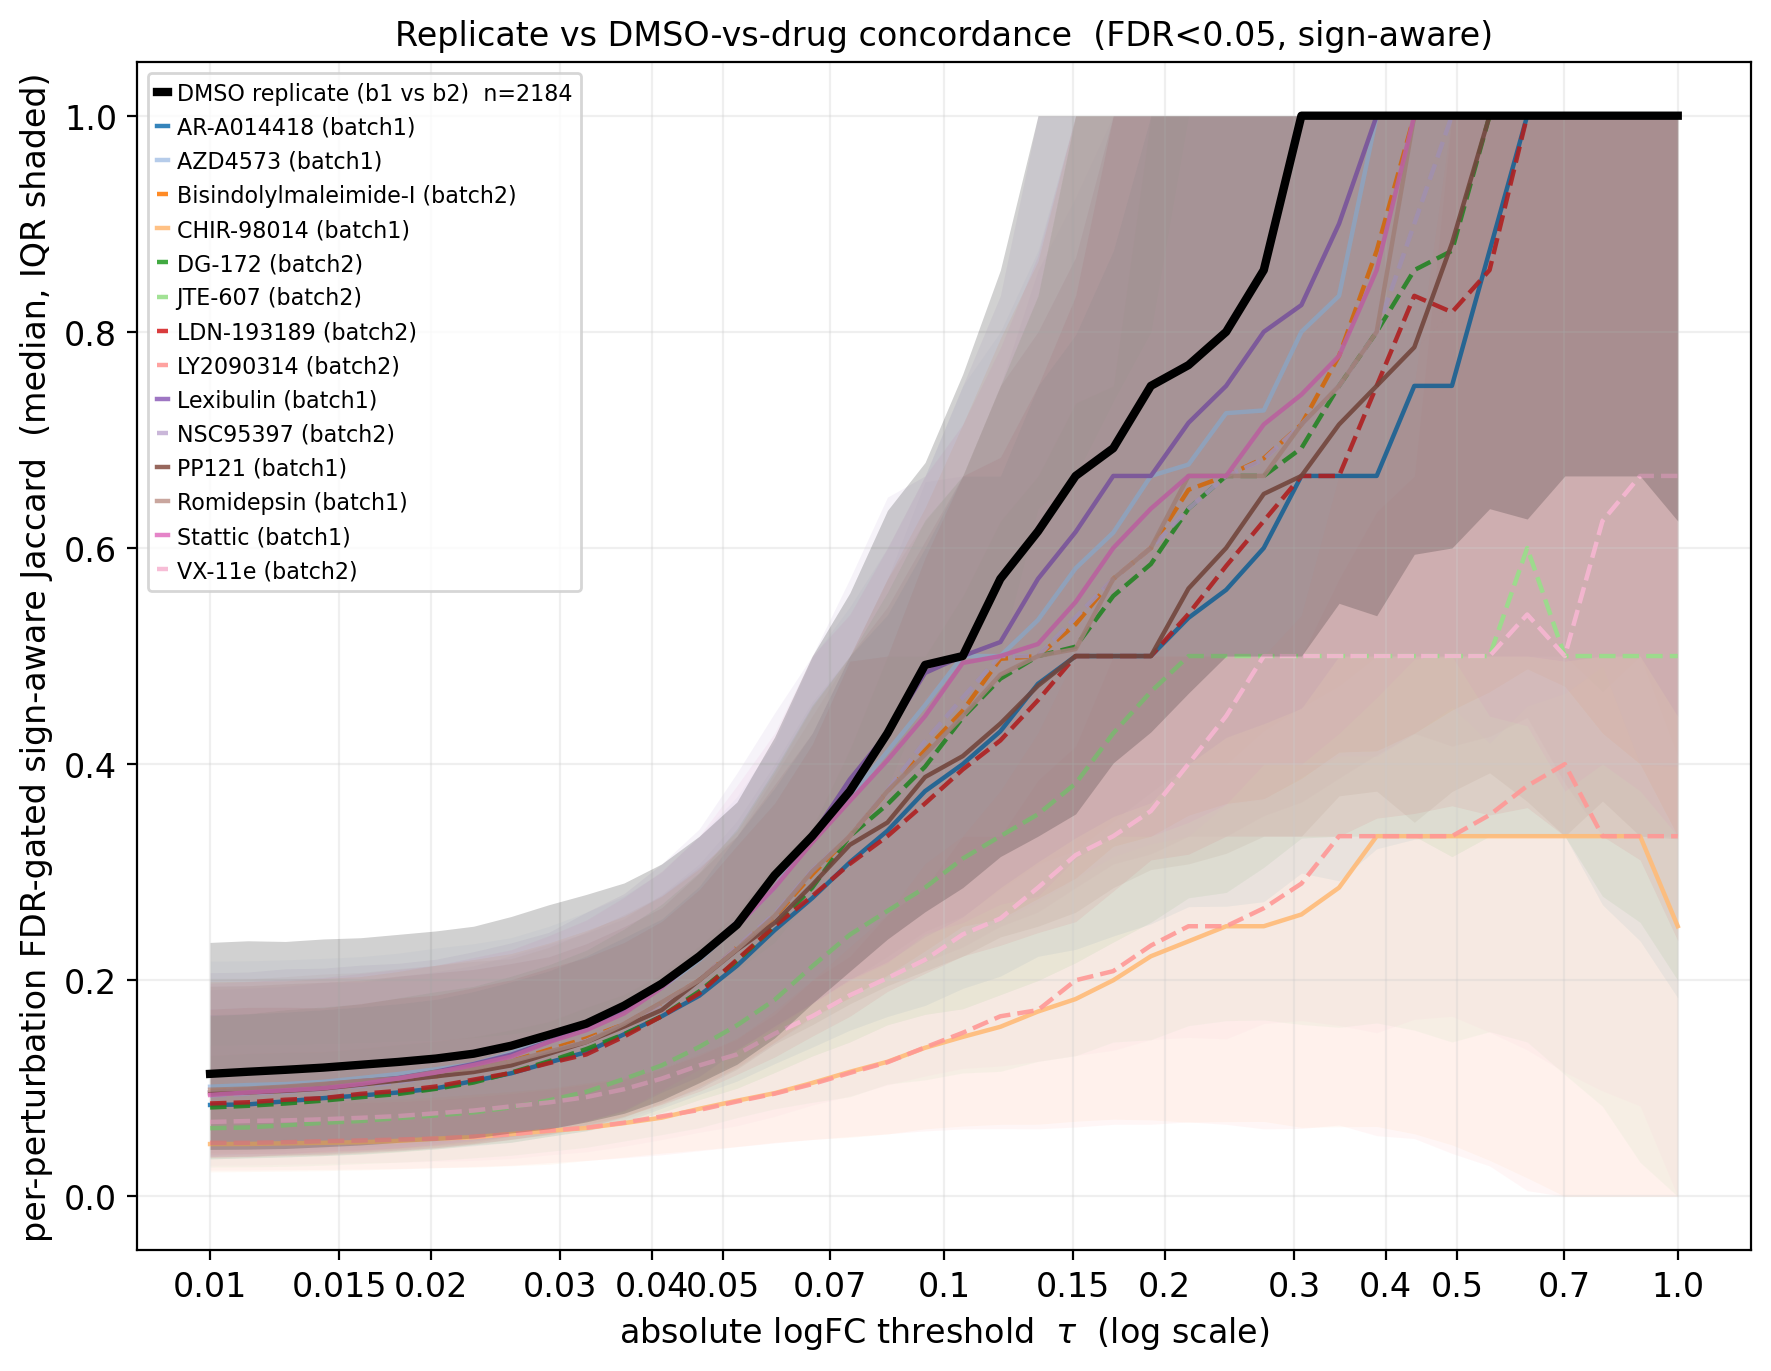

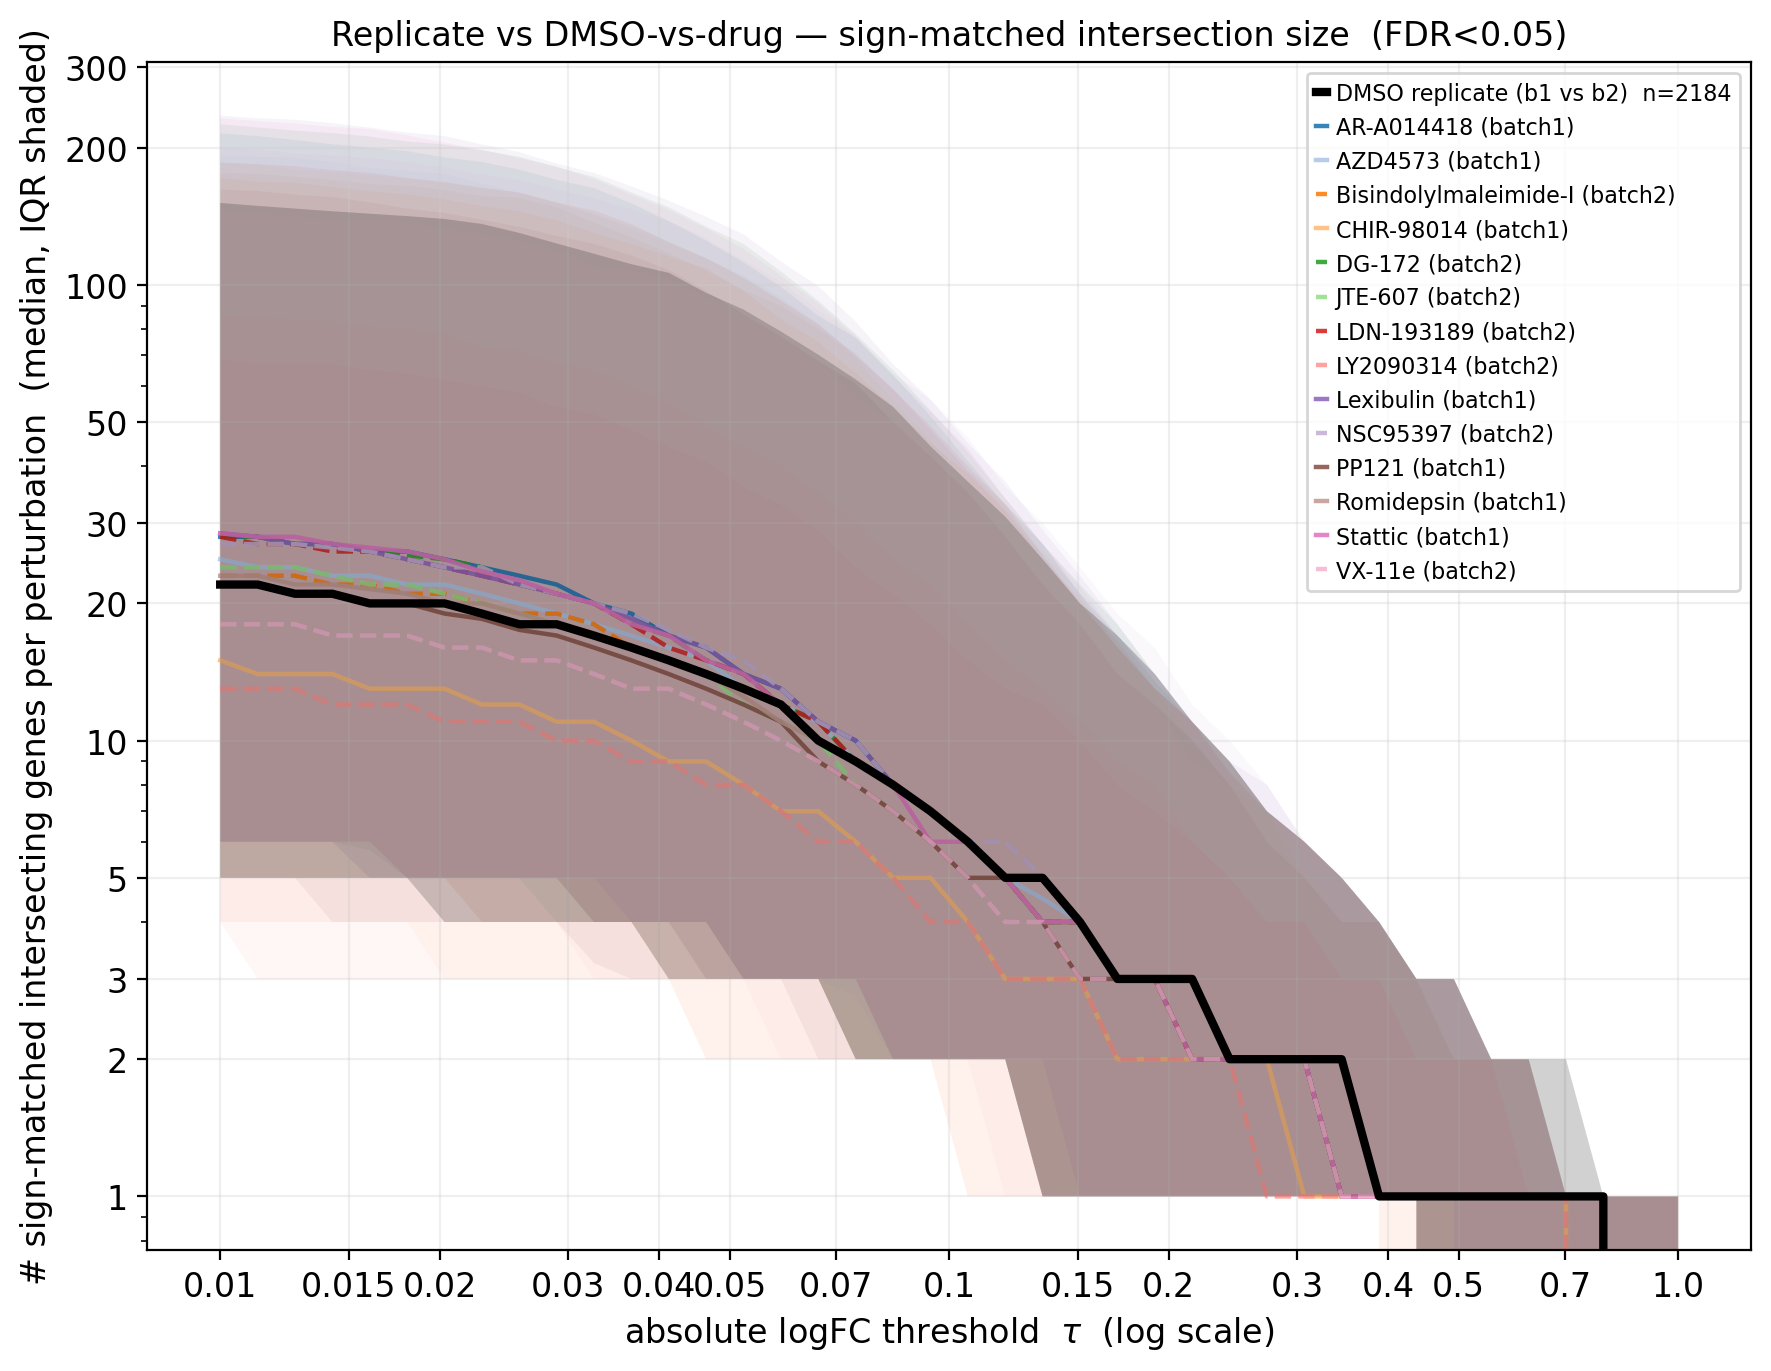

In [27]:
def plot_overlay(rep_long, drug_longs, ax, *, value_col="jaccard",
                 ylabel=None, title=None, logy=False):
    """Median of `value_col` vs tau: DMSO replicate (bold black) + one line per drug."""
    taus  = np.array(sorted(rep_long.threshold.unique())); taus = taus[taus > 0]
    def _med_iqr(w):
        """median, 25th and 75th percentile across perturbations, per threshold."""
        return (w[taus].median().values,
                w[taus].quantile(0.25).values,
                w[taus].quantile(0.75).values)

    rep_w = rep_long.pivot(index="perturbation", columns="threshold", values=value_col)
    med, q1, q3 = _med_iqr(rep_w)
    ax.fill_between(taus, q1, q3, color="black", alpha=0.18, linewidth=0, zorder=9)
    ax.plot(taus, med, color="black", lw=3.0, zorder=10,
            label=f"DMSO replicate (b1 vs b2)  n={rep_w.shape[0]}")
    cmap = plt.get_cmap("tab20")
    for i, (d, dl) in enumerate(sorted(drug_longs.items())):
        dw = dl.pivot(index="perturbation", columns="threshold", values=value_col)
        med, q1, q3 = _med_iqr(dw)
        col = cmap(i % 20)
        ls = "-" if BATCH_OF[d] == "batch1" else "--"
        ax.fill_between(taus, q1, q3, color=col, alpha=0.08, linewidth=0)
        ax.plot(taus, med, color=col, lw=1.6, ls=ls, alpha=0.9, label=f"{d} ({BATCH_OF[d]})")
    ax.set_xscale("log")
    xt = _LOG_TICKS[(_LOG_TICKS >= taus.min()) & (_LOG_TICKS <= taus.max())]
    ax.set_xticks(xt); ax.set_xticklabels([_fmt_tick(t) for t in xt]); ax.minorticks_off()
    if logy:
        ax.set_yscale("log")
        # denser, plainly-labelled log ticks so the upper y-range is readable
        ax.yaxis.set_major_locator(ticker.LogLocator(base=10, subs=(1.0, 2.0, 3.0, 5.0), numticks=40))
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y:g}"))
        ax.yaxis.set_minor_locator(ticker.LogLocator(base=10, subs=tuple(np.arange(2, 10)), numticks=120))
        ax.yaxis.set_minor_formatter(ticker.NullFormatter())
    ax.set_xlabel(r"absolute logFC threshold  $\tau$  (log scale)")
    ax.set_ylabel(ylabel if ylabel is not None
                  else "per-perturbation FDR-gated sign-aware Jaccard  (median, IQR shaded)")
    ax.set_title(title if title is not None
                 else "Replicate vs DMSO-vs-drug concordance  (FDR<0.05, sign-aware)")
    ax.grid(alpha=0.3, which="major")
    ax.legend(fontsize=8, loc="best")


# (1) Jaccard similarity
fig, ax = plt.subplots(figsize=(9, 7))
plot_overlay(jac_signed, drug_long, ax)
fig.tight_layout()
fig.savefig(OUT_DIR2 / "fig_jaccard_vs_tau_notebook.png", dpi=140)
plt.show()

# (2) Sign-matched intersection size (raw # co-significant genes per pert, log y)
fig, ax = plt.subplots(figsize=(9, 7))
plot_overlay(
    jac_signed, drug_long, ax,
    value_col="n_intersection", logy=True,
    ylabel="# sign-matched intersecting genes per perturbation  (median, IQR shaded)",
    title="Replicate vs DMSO-vs-drug — sign-matched intersection size  (FDR<0.05)")
fig.tight_layout()
fig.savefig(OUT_DIR2 / "fig_intersection_vs_tau_notebook.png", dpi=140)
plt.show()

### 8b. Separation and significance vs $\tau$

Left: separation $=\mathrm{median}(J_\mathrm{rep}-J_\mathrm{drug})$ — the
practically meaningful gap. Right: $-\log_{10}$ BH-adjusted p of the paired
Wilcoxon test (red dashed = $p=0.05$). The gap is ~0 at $\tau\to0$ (every gene
is a hit, both $\approx1$), peaks around $\tau\approx0.1$ (natural-log;
$|\log_2 FC|\approx0.15$), then decays as both saturate at Jaccard $=1$.

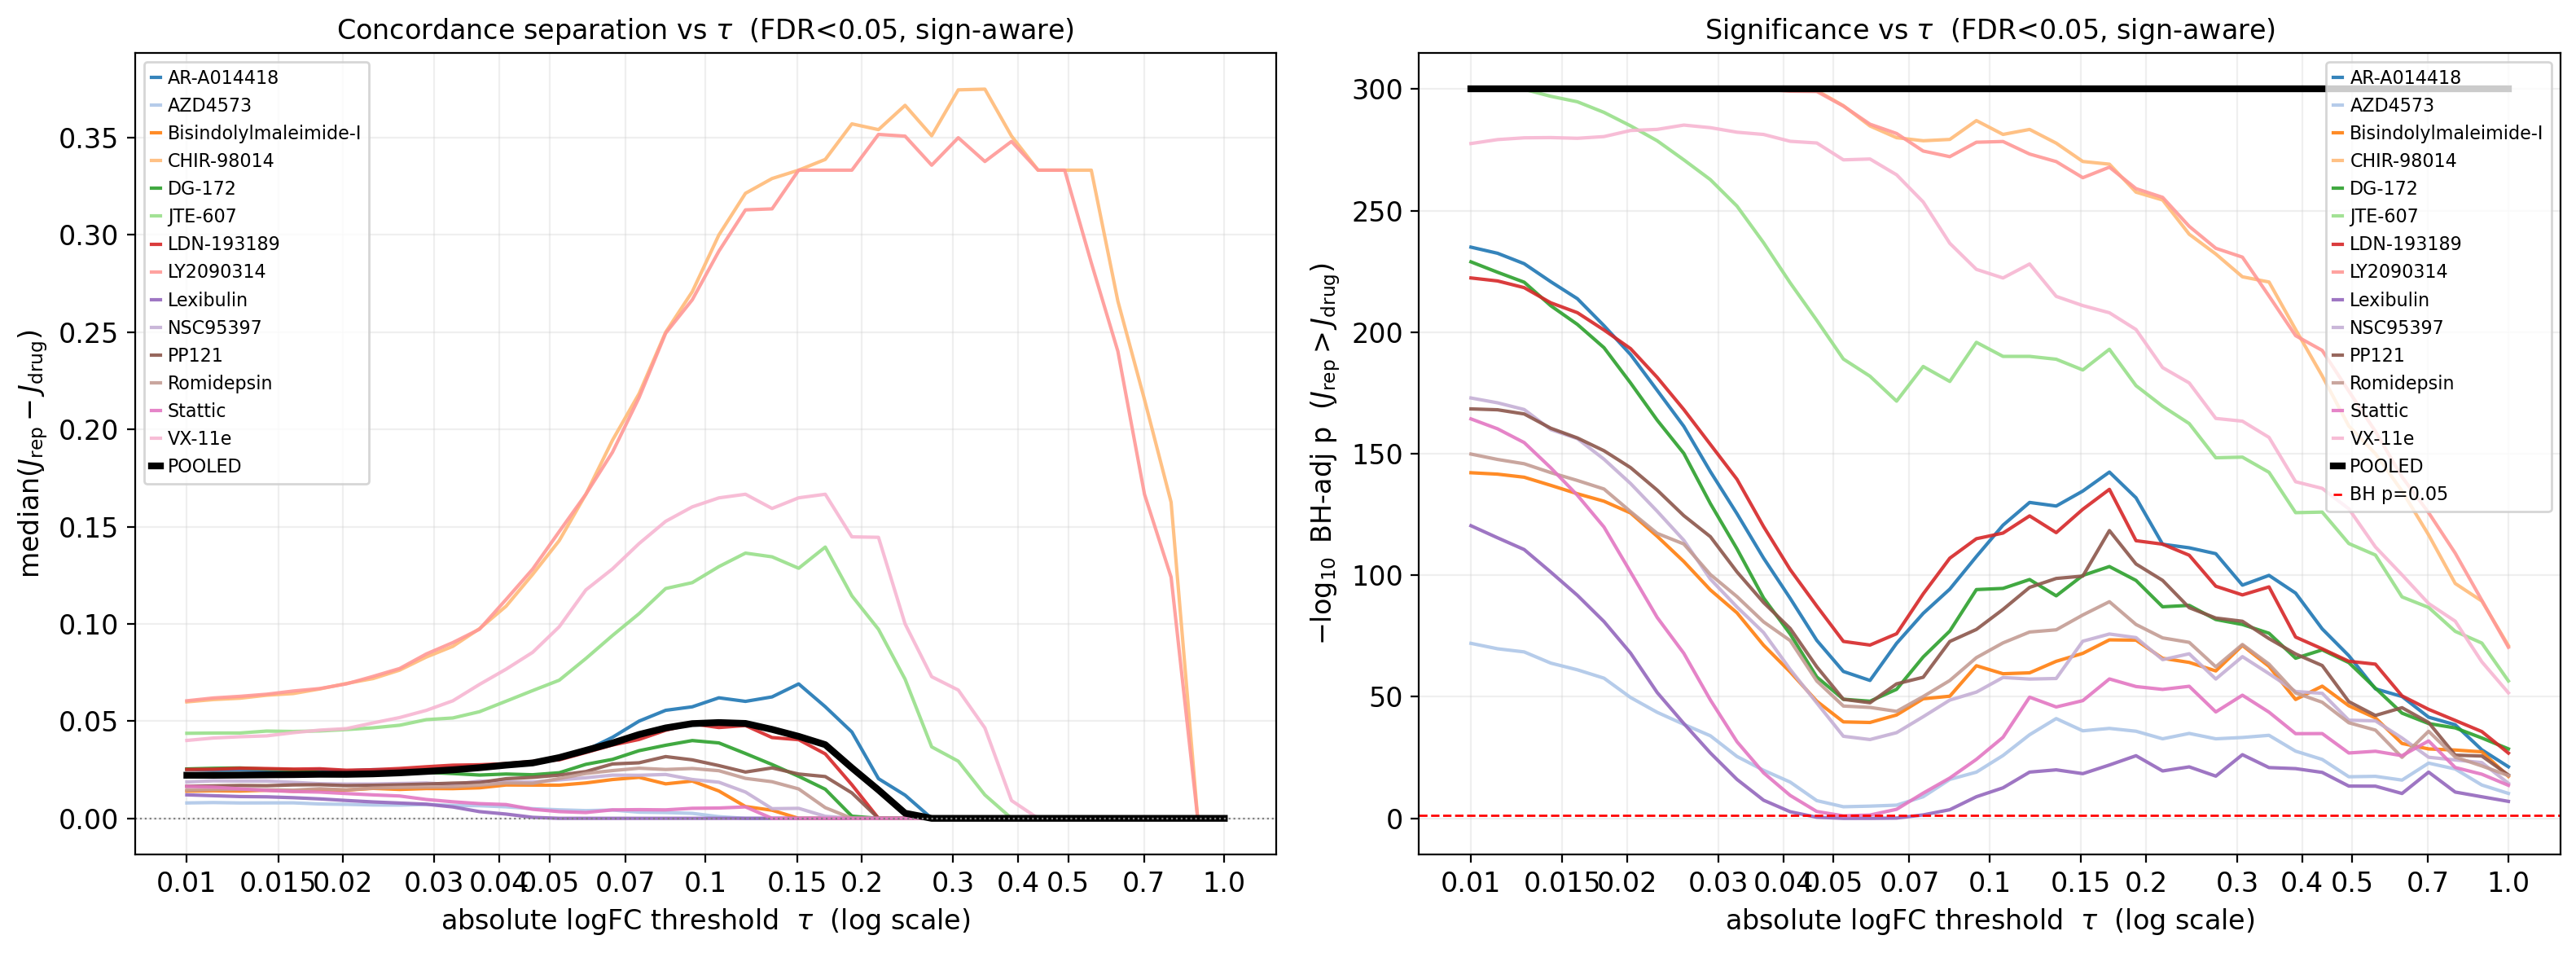

In [26]:
def plot_sep(sig, ax_sep, ax_p, alpha=0.05):
    cmap = plt.get_cmap("tab20")
    drugs = [d for d in sorted(sig.drug.unique()) if d != "POOLED"]
    for i, d in enumerate(drugs):
        s = sig[(sig.drug == d) & (sig.threshold > 0)].sort_values("threshold")
        ax_sep.plot(s.threshold, s.median_diff, color=cmap(i % 20), lw=1.5, alpha=0.9, label=d)
        ax_p.plot(s.threshold, -np.log10(s.p_adj_bh.clip(lower=1e-300)),
                  color=cmap(i % 20), lw=1.5, alpha=0.9, label=d)
    s = sig[(sig.drug == "POOLED") & (sig.threshold > 0)].sort_values("threshold")
    ax_sep.plot(s.threshold, s.median_diff, color="black", lw=3, label="POOLED")
    ax_p.plot(s.threshold, -np.log10(s.p_adj_bh.clip(lower=1e-300)), color="black", lw=3, label="POOLED")
    ax_sep.axhline(0, color="gray", ls=":", lw=0.8)
    ax_p.axhline(-np.log10(alpha), color="red", ls="--", lw=1.0, label=f"BH p={alpha}")
    for ax in (ax_sep, ax_p):
        ax.set_xscale("log")
        xt = _LOG_TICKS[(_LOG_TICKS >= s.threshold.min()) & (_LOG_TICKS <= s.threshold.max())]
        ax.set_xticks(xt); ax.set_xticklabels([_fmt_tick(t) for t in xt]); ax.minorticks_off()
        ax.set_xlabel(r"absolute logFC threshold  $\tau$  (log scale)")
        ax.grid(alpha=0.3, which="major"); ax.legend(fontsize=8, loc="best")
    ax_sep.set_ylabel(r"median$(J_\mathrm{rep}-J_\mathrm{drug})$")
    ax_sep.set_title(r"Concordance separation vs $\tau$  (FDR<0.05, sign-aware)")
    ax_p.set_ylabel(r"$-\log_{10}$ BH-adj p  ($J_\mathrm{rep}>J_\mathrm{drug}$)")
    ax_p.set_title(r"Significance vs $\tau$  (FDR<0.05, sign-aware)")


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_sep(sig, axes[0], axes[1])
fig.tight_layout()
fig.savefig(OUT_DIR2 / "fig_separation_vs_tau_notebook.png", dpi=140)
plt.show()

### 8c. Threshold of peak concordance separation

The single $\tau$ at which the DMSO replicate is *most* more-concordant than
DMSO-vs-drug — i.e. where $\mathrm{median}(J_\mathrm{rep}-J_\mathrm{drug})$ is
largest — pooled across all drugs, plus the per-drug peaks.

In [28]:
# ---- threshold at which the concordance separation peaks ---------------------
# Separation = median over perturbations of (J_replicate - J_drug) at each tau,
# read from `sig` (one row per (drug, threshold)). We report the POOLED peak
# (across all drugs) and the per-drug peaks.
import numpy as np

_sig = sig[sig["threshold"] > 0]

# pooled peak (drug == "POOLED")
_pool = _sig[_sig["drug"] == "POOLED"].sort_values("threshold")
_i = int(np.nanargmax(_pool["median_diff"].values))
tau_star = float(_pool["threshold"].values[_i])
print(f"POOLED peak-separation tau = {tau_star:.4f}  "
      f"(|log2FC| = {tau_star/np.log(2):.4f}),  "
      f"separation = {_pool['median_diff'].values[_i]:.4f}")

# per-drug peaks, ranked
_rows = []
for d, sub in _sig[_sig["drug"] != "POOLED"].groupby("drug"):
    sub = sub.sort_values("threshold")
    j = int(np.nanargmax(sub["median_diff"].values))
    _rows.append({"drug": d,
                  "peak_tau": float(sub["threshold"].values[j]),
                  "peak_tau_log2": float(sub["threshold"].values[j] / np.log(2)),
                  "peak_separation": float(sub["median_diff"].values[j])})
peak_tau_table = (pd.DataFrame(_rows)
                  .sort_values("peak_separation", ascending=False)
                  .reset_index(drop=True))
print(f"\nmedian of per-drug peak tau = {peak_tau_table['peak_tau'].median():.4f}")
peak_tau_table

POOLED peak-separation tau = 0.1061  (|log2FC| = 0.1530),  separation = 0.0493

median of per-drug peak tau = 0.0890


,drug,peak_tau,peak_tau_log2,peak_separation
0,CHIR-98014,0.345511,0.498467,0.375000
1,LY2090314,0.215443,0.310819,0.351713
2,VX-11e,0.119378,0.172226,0.166667
3,JTE-607,0.170125,0.245439,0.139510
4,AR-A014418,0.151178,0.218103,0.069137
5,LDN-193189,0.094267,0.135998,0.048611
6,DG-172,0.094267,0.135998,0.040000
7,PP121,0.083768,0.120851,0.031751
8,Romidepsin,0.074438,0.107391,0.025783
9,NSC95397,0.083768,0.120851,0.022567


### 8d. Conclusions

* **Yes — the DMSO replicate pair is significantly more concordant than
  DMSO-vs-drug** on the FDR-gated, sign-aware Jaccard (paired Wilcoxon,
  $J_\mathrm{rep} > J_\mathrm{drug}$), for every drug and pooled.
* The replicate curve is the **upper envelope** of the 14 drug curves across $\tau$.
* **Significance is driven by effect size, not the p-value crossover** — with
  thousands of matched pairs the test is significant across nearly the whole
  $\tau$ range. The practically meaningful quantity is the **separation**
  $\mathrm{median}(J_\mathrm{rep}-J_\mathrm{drug})$, which is small at the
  extremes (near $\tau=0$ both are dominated by the shared FDR-significant set;
  at large $\tau$ both shrink to tiny sets) and **peaks at an intermediate
  $\tau$** — read the exact peak-separation $\tau$ per drug off the `summary`
  table above.
* **Per-drug ranking** (peak separation = how strongly the drug remodels the
  perturbation response) is now computed over all 14 drugs; sort `summary` by
  `peak_median_diff`. In the effect-size-only analysis the GSK3 inhibitors
  CHIR-98014 / LY2090314 diverged most from DMSO and tubulin/HDAC contexts least.

Outputs written to `Notes/dmso_vs_drug_concordance/`:
`significance_signed.csv`, `crossover_summary.csv`,
`fig_jaccard_vs_tau_notebook.png`, `fig_separation_vs_tau_notebook.png`.